# Initialize Notebook

---

In [1]:
# Package imports
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importing the classes and helper functions from the PRIZM files
from src.PRIZM_classes import ZeroShotModellerModule, PlottingModule

In [2]:
# Initialize PRIZM
model_list = ['CARP','ESM1b','ESM1v','ESM2','Progen2','ProtGPT2','RITA','TranceptionNoRet','UniRep', #Sequence
              'eUniRep','EVE','GEMME','TranceptEVE','Tranception', 'MSATransformer', #MSA
              'ESM-IF1','MIF','MIFST','MULAN','ProteinMPNN','ProSST','ProtSSN','SaProt',#Structure
              'RSALOR','VenusREM', #all 'ESCOTT',
              ]
zsm_module = ZeroShotModellerModule('src/model_config.yaml') # Initialize the ZSM module
zsmplt = PlottingModule() # Initialize the plotting module

---

# Exploration - Low-N Dataset

In the Exploration phase of the PRIZM pipeline, the zero-shot scores of a Low-N dataset is compared to its experimental values. Importantly, this requires all the specified ZS predictors to have been run for the given dataset. The Exploration workflow will then be able to calculate the correlation metrics for every model and use these metrics to identify the best and worst overall models, as well as the best and worst models for each input category (Sequence, MSA, Structure).

## Load dataset

The data is loaded into the ZeroShotModeller (ZSM) module for future processing. Please specify datafile name and WT threshold, as well as the directory contained the ZS results.

---

In [3]:
# Change the values of the following variables as needed
lowN_name = ['TOGT1_1_relact','TOGT1_1_relact_clean']
load_name = ['TOGT1_1_relact','TOGT1_1_relact']
wt_threshold = [47.87383674,47.87383674]

In [4]:
for load, threshold,lowN in zip(load_name, wt_threshold, lowN_name):
    zsm_module.set_threshold(lowN, threshold)
    zsm_module.load_scores(load, model_list,dict_name=lowN,wt = True)

In [5]:
problem_mut = 'M197R'
problem_sequence = 'MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVFSKSIQRNKYLGIEIEIRLIKFPAVENDLPEECERLDQIPSDDKLSNFFKATAMMQEPLEQLIEECRPNCLVSDMFLPWTTDSAAKFNIPRIVFHGTSFFALCVENSVRLNKPYKNVSSDAETFVVPNLPHEIKLTRTQLSPFEQSGEETARTRMIKTVRESDSKSYGVVFNSFYELETDYVEHYTKVLGRRAWAIGPLSMCNRDIEDKAERGKKSSIDKHECLKWLDSKKPSSVVYVCFGSVANFTASQLHELAMGIEASGQEFIWVVRTELDNEDWLPEGFEERTKEKGLIIRGWAPQVLILDHESVGAFVTHCGWNSTLEGVSGGVPMVTWPVFAEQFFNEKLVTEVLKTGAGVGSIQWKRSASEGVKREAIAKAIKRVMVSEEAEGFRNRAKAYKEMARKAVEEGGSSYTGLTTLLEDISTYTSTGH'
for model in zsm_module.datasets['TOGT1_1_relact_clean'].keys():
    df_ = zsm_module.datasets['TOGT1_1_relact_clean'][model].copy()
    if 'mutant' in df_.columns:
        df_ = df_[df_['mutant']!=problem_mut].reset_index(drop=True)
    else:
        df_ = df_[df_['mutated_sequence']!=problem_sequence].reset_index(drop=True)
    zsm_module.datasets['TOGT1_1_relact_clean'][model] = df_
    

---

## Process dataset

In this section, the correlation metrics are calculated, and the best/worst models are identified. Please not that the metrics used to identify the best/worst models are Spearman Correlation and Average Precision by default. If a different metric is desired, please see ZSM documentation for how to do this.

The Low-N dataset for FlA HIM is here used as an example



---

In [6]:
# Change the values of the following variables as needed
n_bootstrap = 1000 # Decrease to reduce computation time

In [7]:
for name in lowN_name:
    zsm_module.compute_metrics(name,n_bootstrap=n_bootstrap, metrics = ['spearmanr','average_precision'])
    zsm_module.process_models(name)

In [8]:
for name in lowN_name:
    print(f'Results for {name}')
    best_models = [zsm_module.best_models[name][cat] for cat in ['overall','sequence','MSA','structure']]
    worst_models = [zsm_module.worst_models[name][cat] for cat in ['overall','sequence','MSA','structure']]
    print('Best Overall Model:',best_models[0])
    print('Best Sequence Model:',best_models[1])
    print('Best MSA Model:',best_models[2])
    print('Best Structure Model:',best_models[3])
    print('---------------------------------')
    print('Worst Overall Model:',worst_models[0])
    print('Worst Sequence Model:',worst_models[1])
    print('Worst MSA Model:',worst_models[2])
    print('Worst Structure Model:',worst_models[3])
    print('---------------------------------')
    

Results for TOGT1_1_relact
Best Overall Model: VenusREM_4096
Best Sequence Model: ESM2_650M
Best MSA Model: Tranception_L
Best Structure Model: ProSST_1024
---------------------------------
Worst Overall Model: ProtGPT2
Worst Sequence Model: ProtGPT2
Worst MSA Model: GEMME
Worst Structure Model: ProtSSN
---------------------------------
Results for TOGT1_1_relact_clean
Best Overall Model: ESM2_150M
Best Sequence Model: ESM2_150M
Best MSA Model: GEMME
Best Structure Model: ProSST_128
---------------------------------
Worst Overall Model: MSATransformer
Worst Sequence Model: ESM1v
Worst MSA Model: MSATransformer
Worst Structure Model: MULAN_small
---------------------------------


In [9]:
correct_sign = []
wrong_sign = []
df_ = zsm_module.metric_results['TOGT1_1_relact_clean']
df_ = df_.iloc[:,df_.columns.get_level_values('stat') == 'reverse']['spearmanr']
for model in df_.index:
    if not df_.loc[model].reverse and model != 'EVE':
        correct_sign.append(model)
    elif not df_.loc[model].reverse and model == 'EVE':
        wrong_sign.append(model)
    elif df_.loc[model].reverse and model != 'EVE':
        wrong_sign.append(model)
    else:
        correct_sign.append(model)

---

## Plot results

In this section, correlation results are plotted. This includes a comparison of the performance of all models, as well as the performance of singular models. Again, please note that the default metrics are Spearman Correlation and Average Precision. See ZSM documentation for how to change this. Furthermore, please specify the folder for saving the metric figures.

---

Plotting results for TOGT1_1_relact


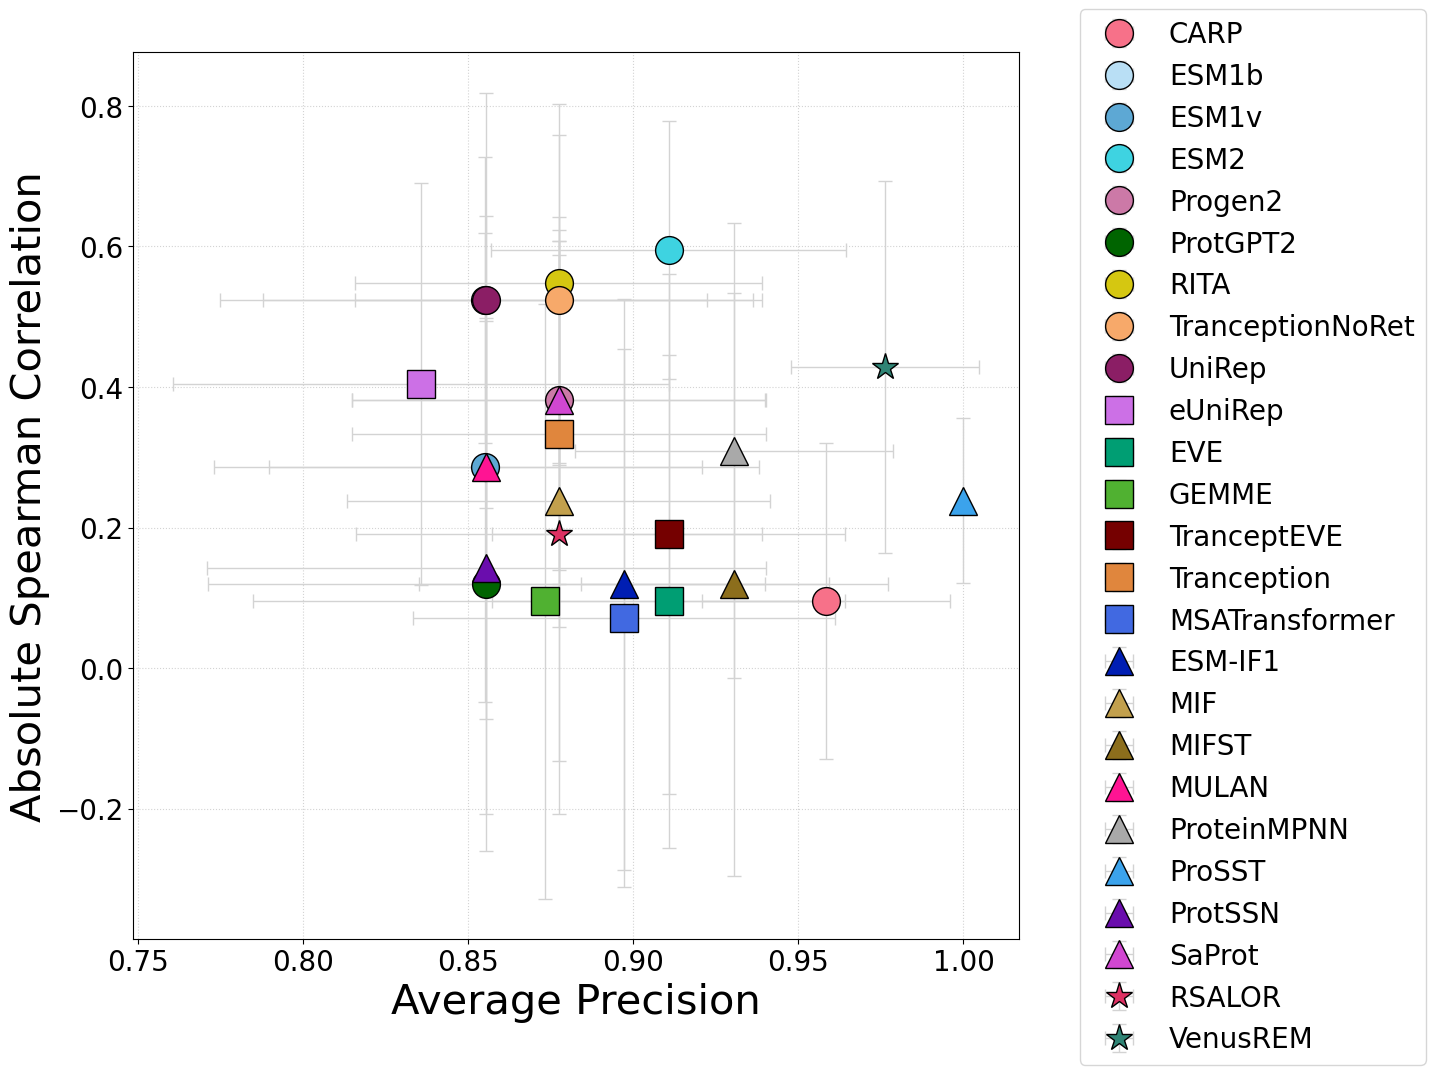

Plotting results for TOGT1_1_relact correct models


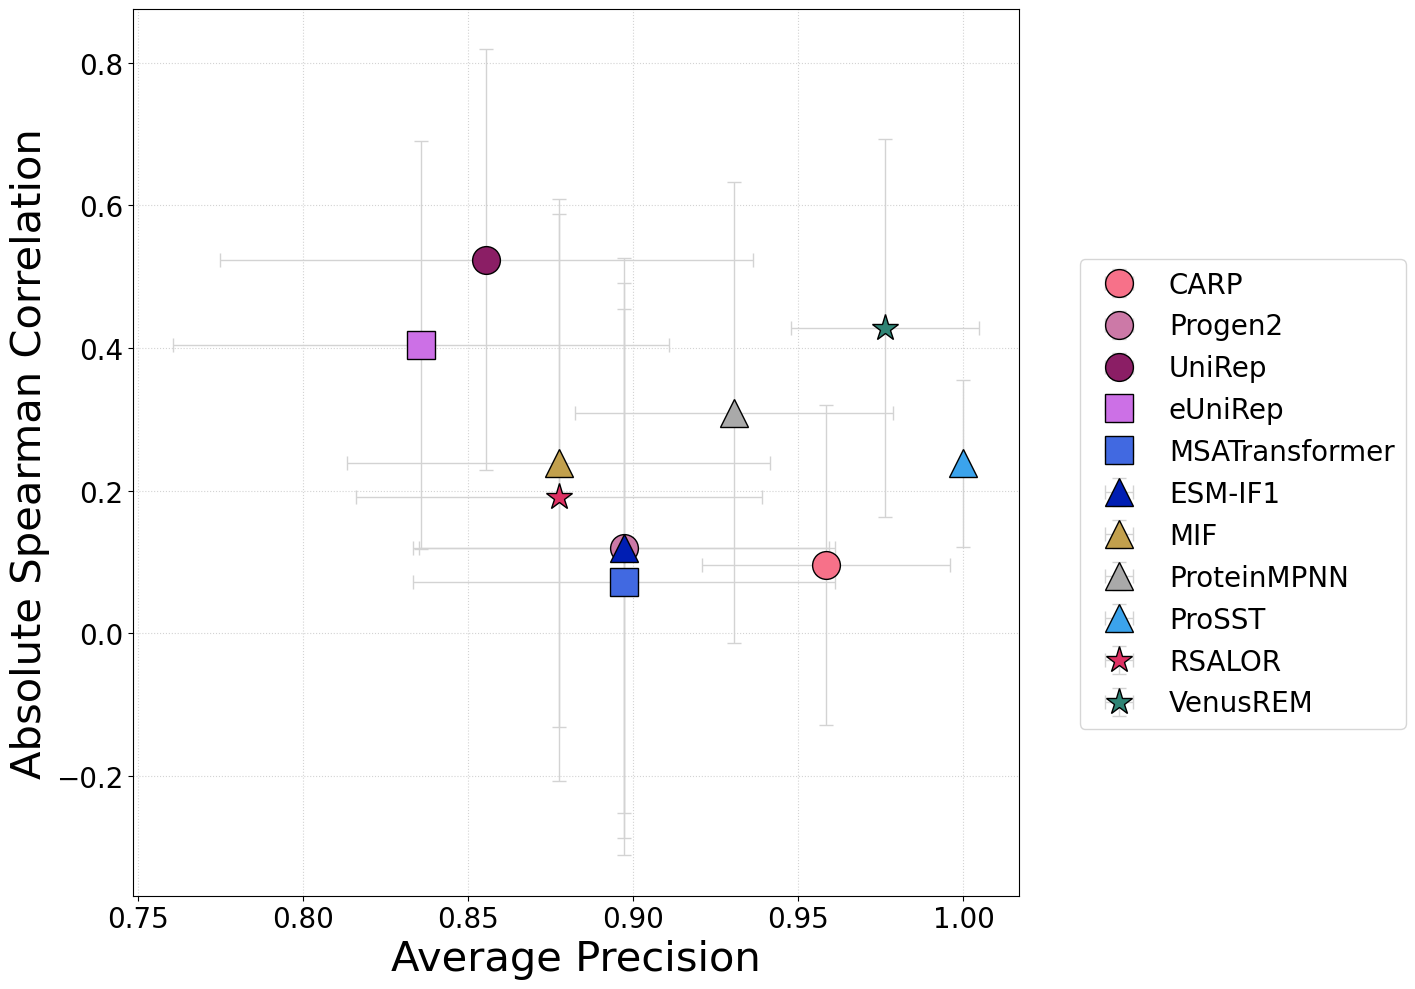

Plotting results for TOGT1_1_relact_clean


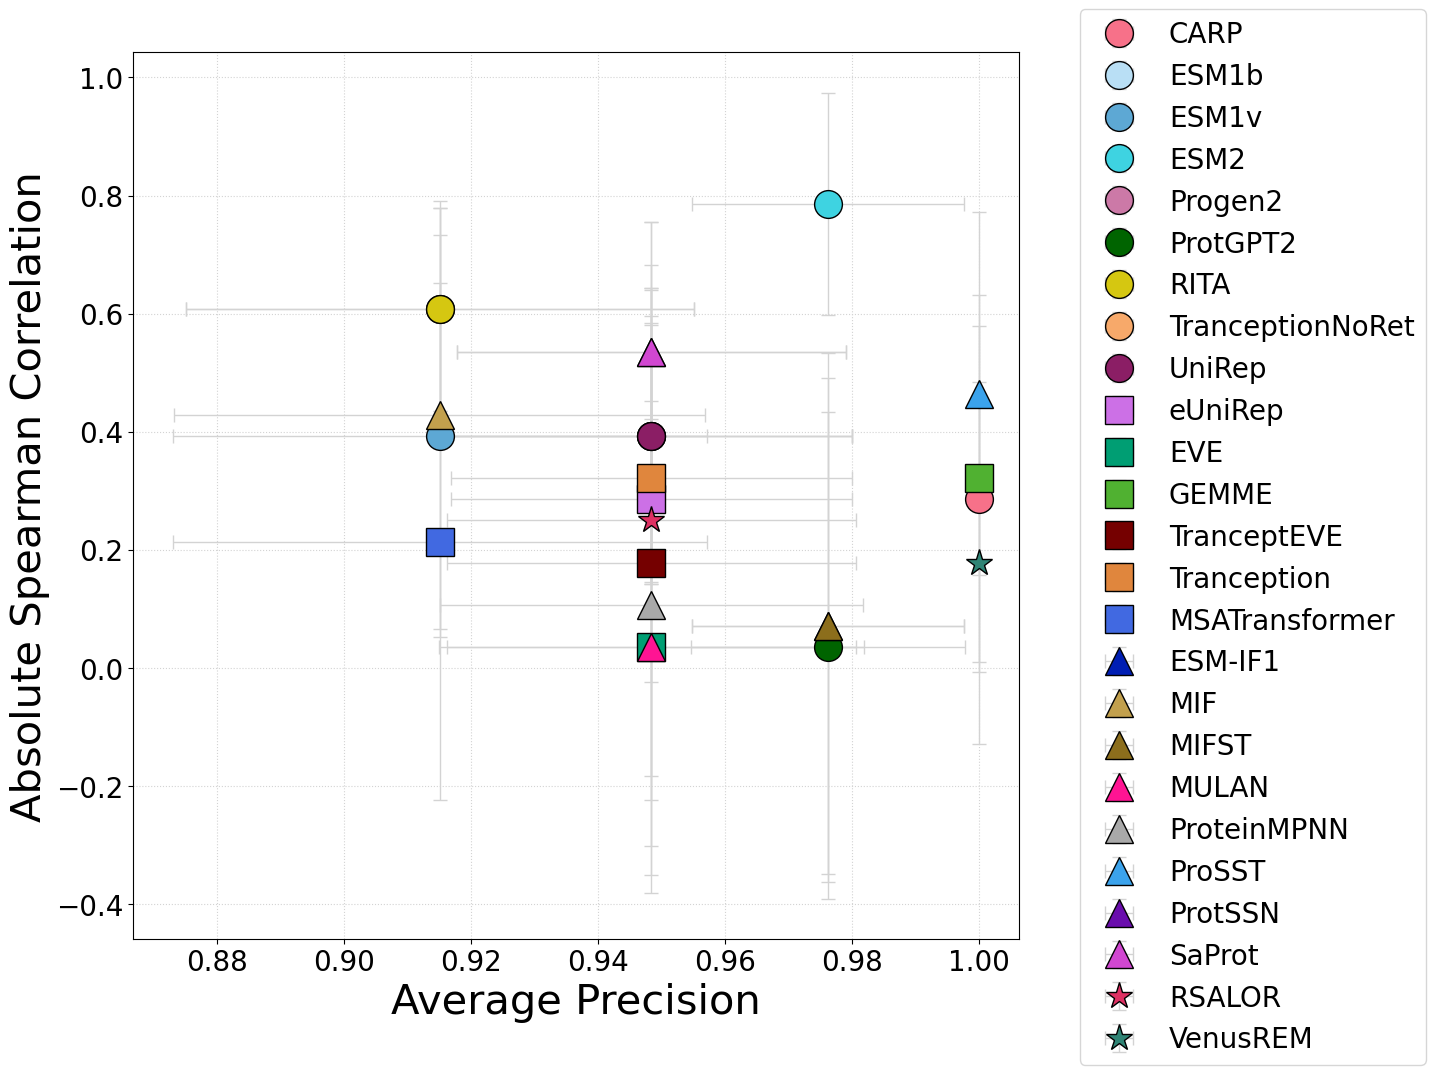

Plotting results for TOGT1_1_relact_clean correct models


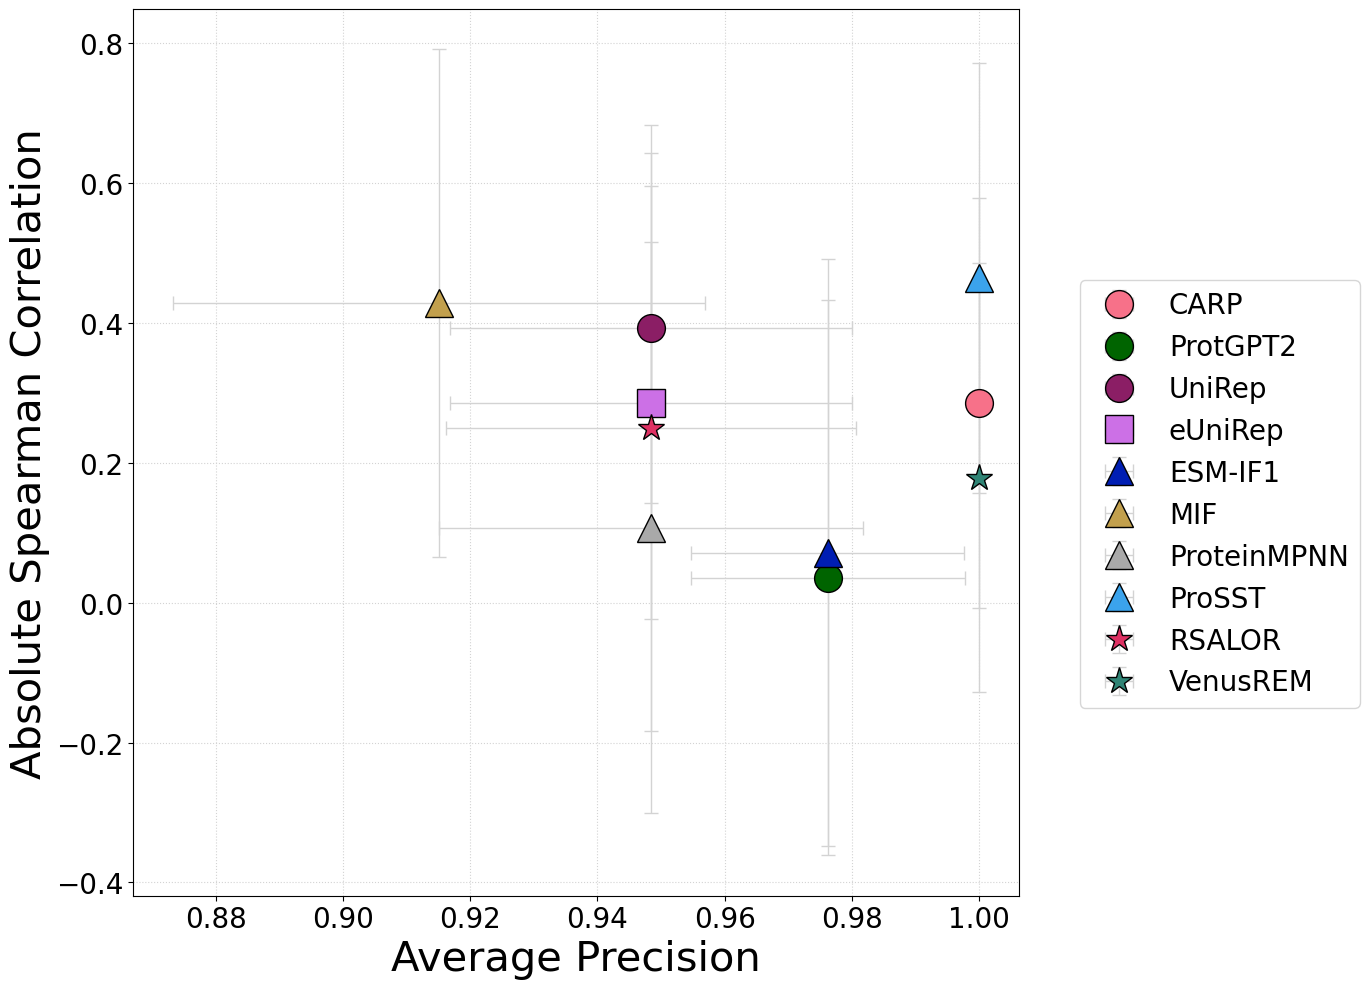

In [10]:
# Plotting the model performances
for name in lowN_name:
    print(f'Plotting results for {name}')
    zsmplt.metrics(zsm_module, name, figsize=(14, 10))

    print(f'Plotting results for {name} correct models')
    zsmplt.metrics(zsm_module, name, figsize=(14, 10), use_correct=True)

Plotting results for TOGT1_1_relact


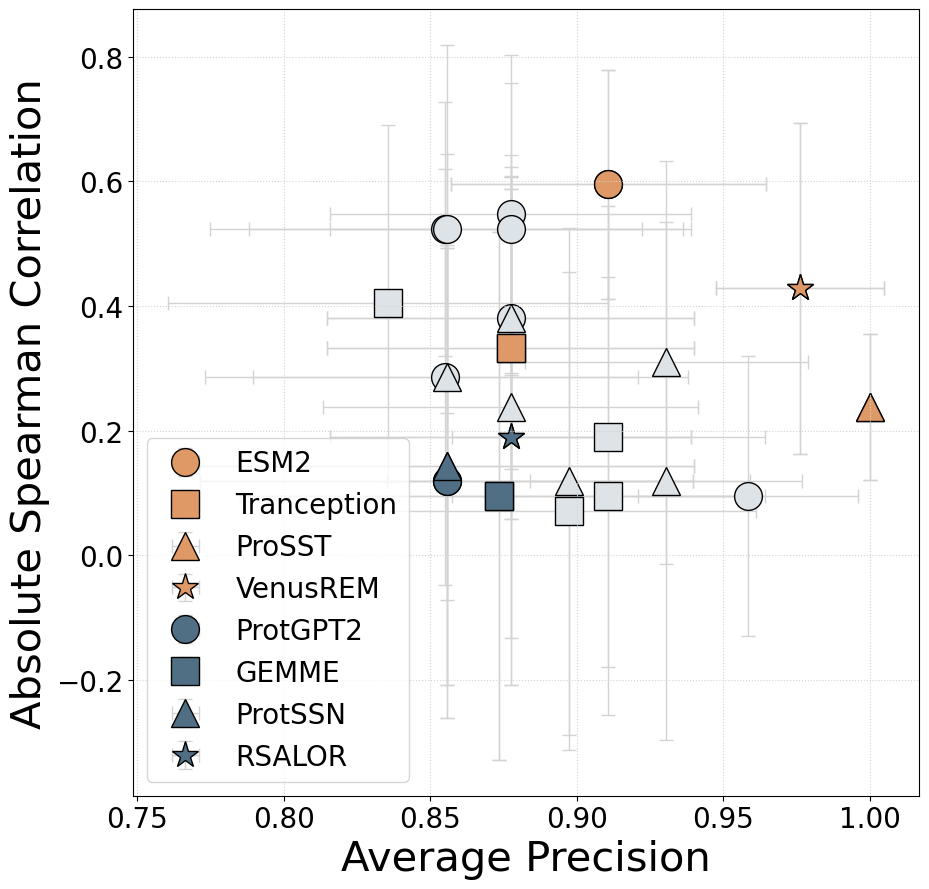

Plotting results for TOGT1_1_relact correct models


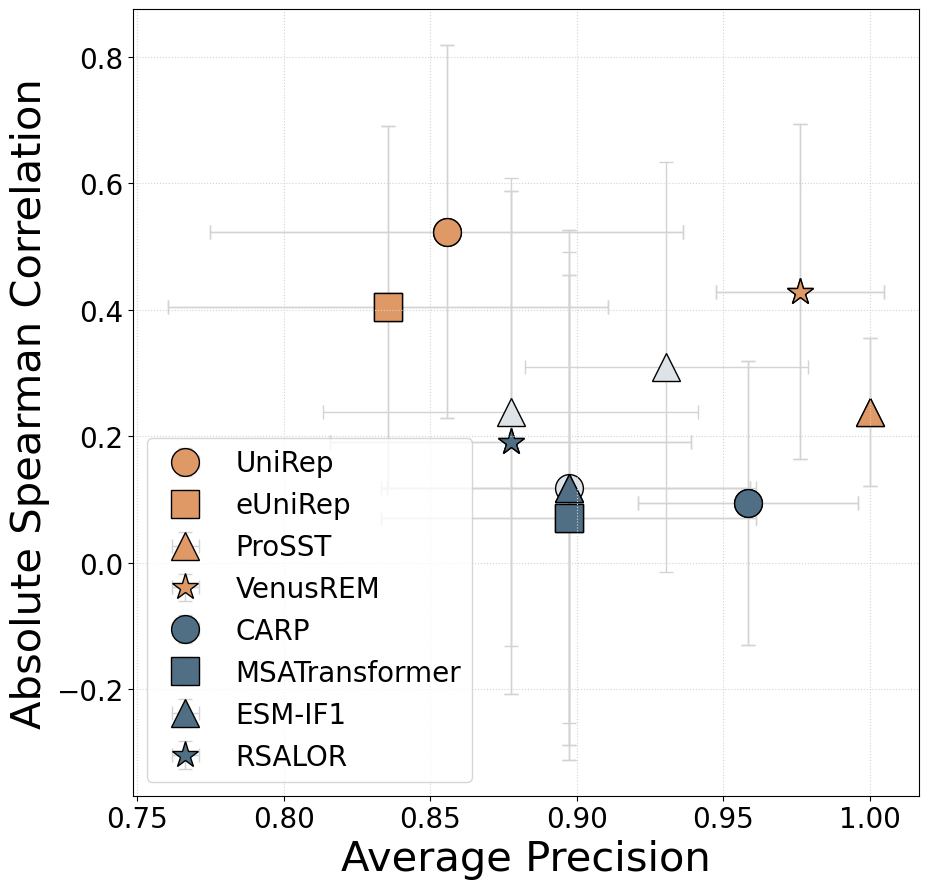

Plotting results for TOGT1_1_relact_clean


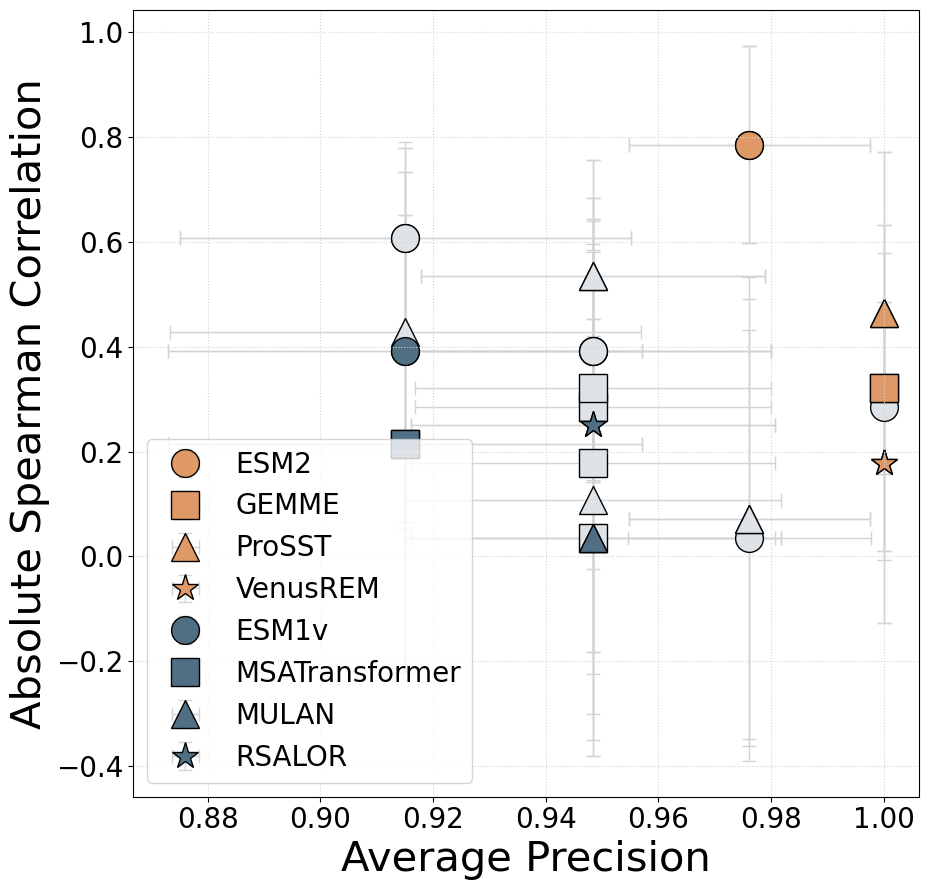

Plotting results for TOGT1_1_relact_clean correct models


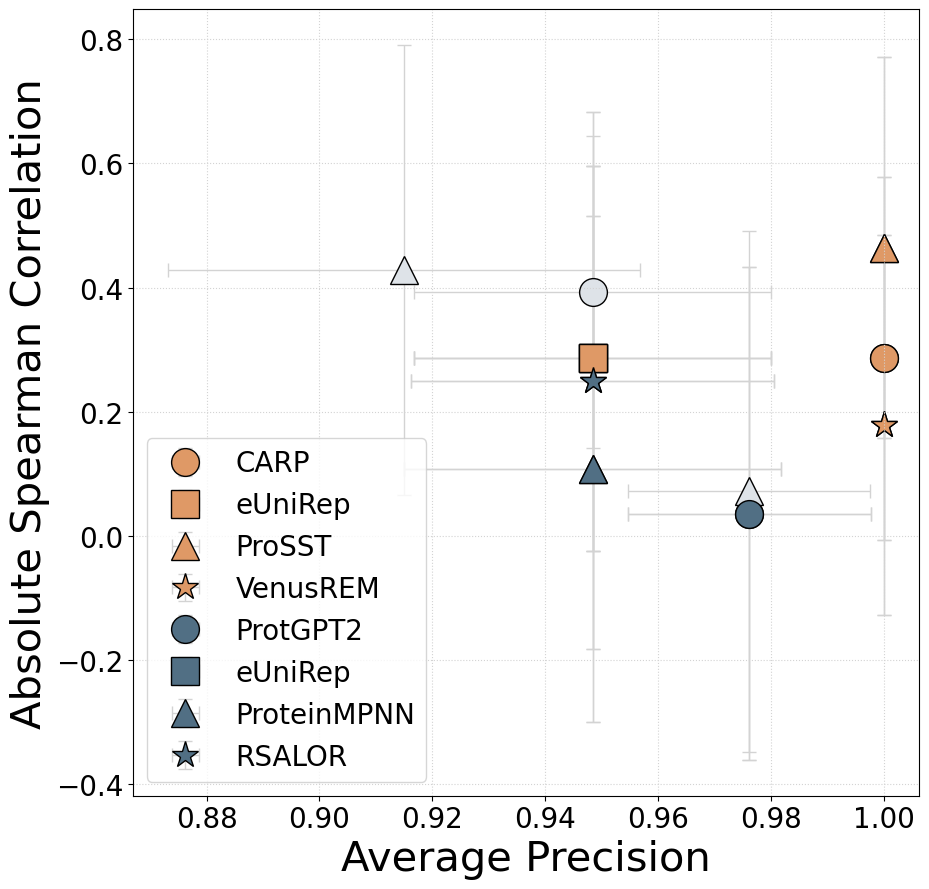

In [9]:
# Plotting the model performances, with the best and worst models highlighted
for name in lowN_name:
    print(f'Plotting results for {name}')
    zsmplt.metrics_cat(zsm_module, name, figsize=(12, 9), legend_fontsize=20)

    print(f'Plotting results for {name} correct models')
    zsmplt.metrics_cat(zsm_module, name, figsize=(12, 9), use_correct=True, legend_fontsize=20)

Plotting results for TOGT1_1_relact
Overall Model
Best Overall Model: VenusREM_4096


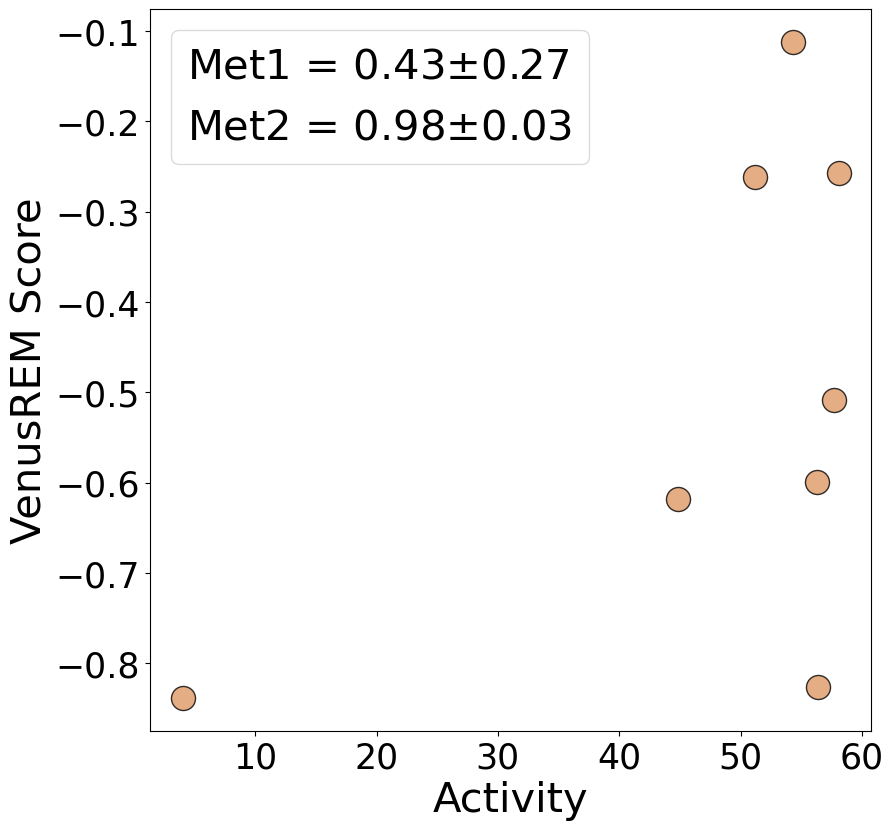

Worst Overall Model: ProtGPT2


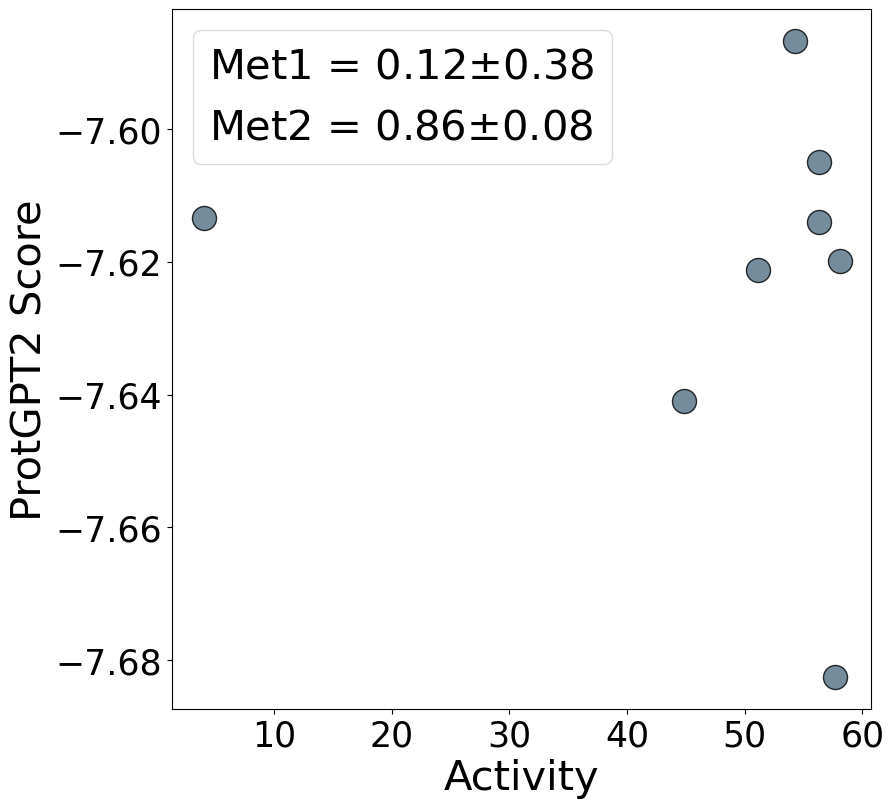

Sequence Model
Best Sequence Model: ESM2_650M


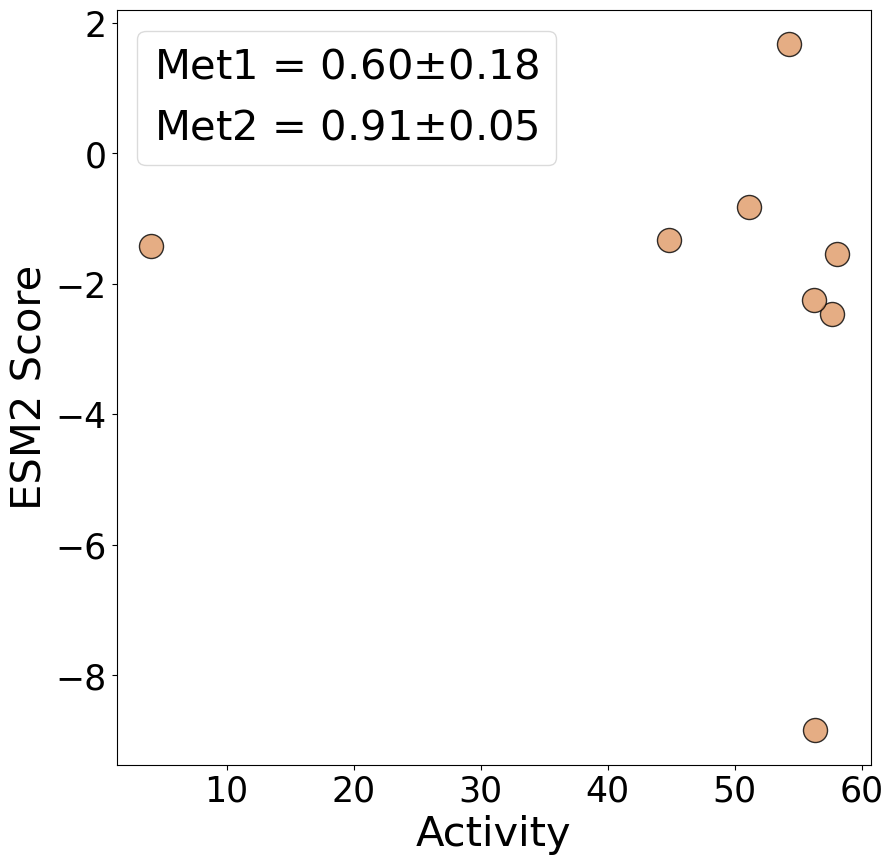

Worst Sequence Model: ProtGPT2


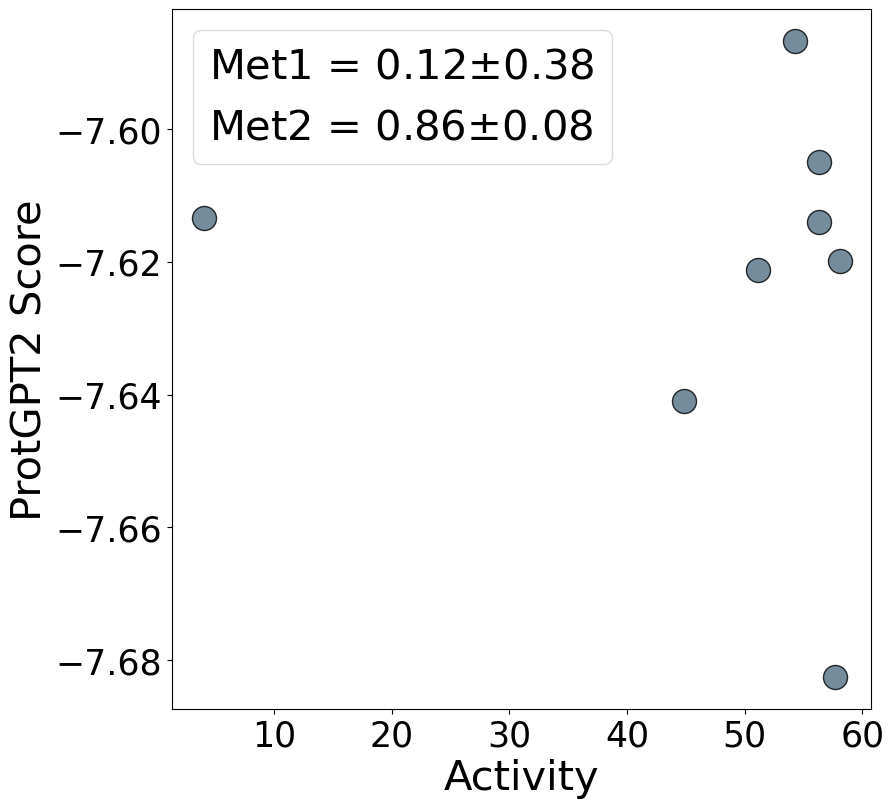

MSA Model
Best MSA Model: TranceptEVE_S


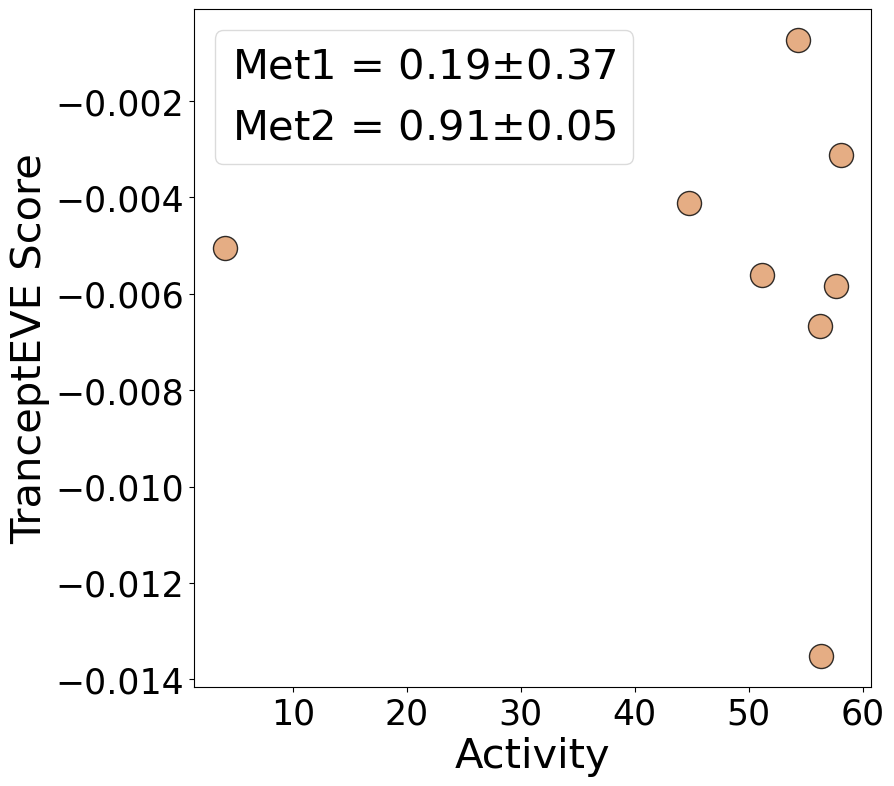

Worst MSA Model: GEMME


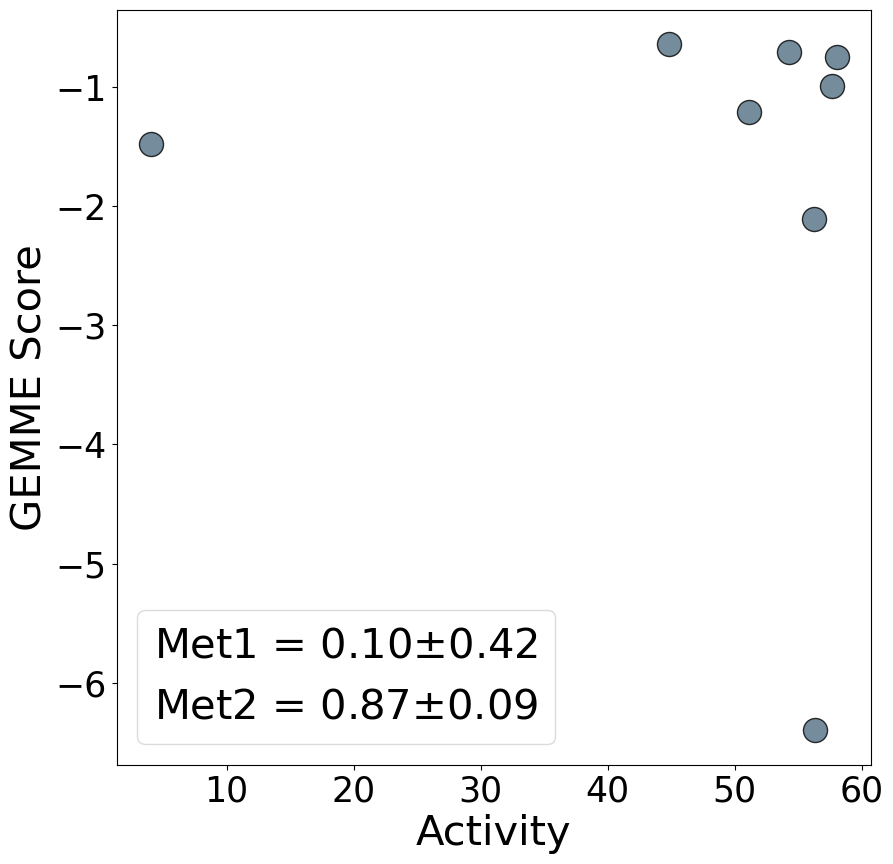

Structure Model
Best Structure Model: ProSST_1024


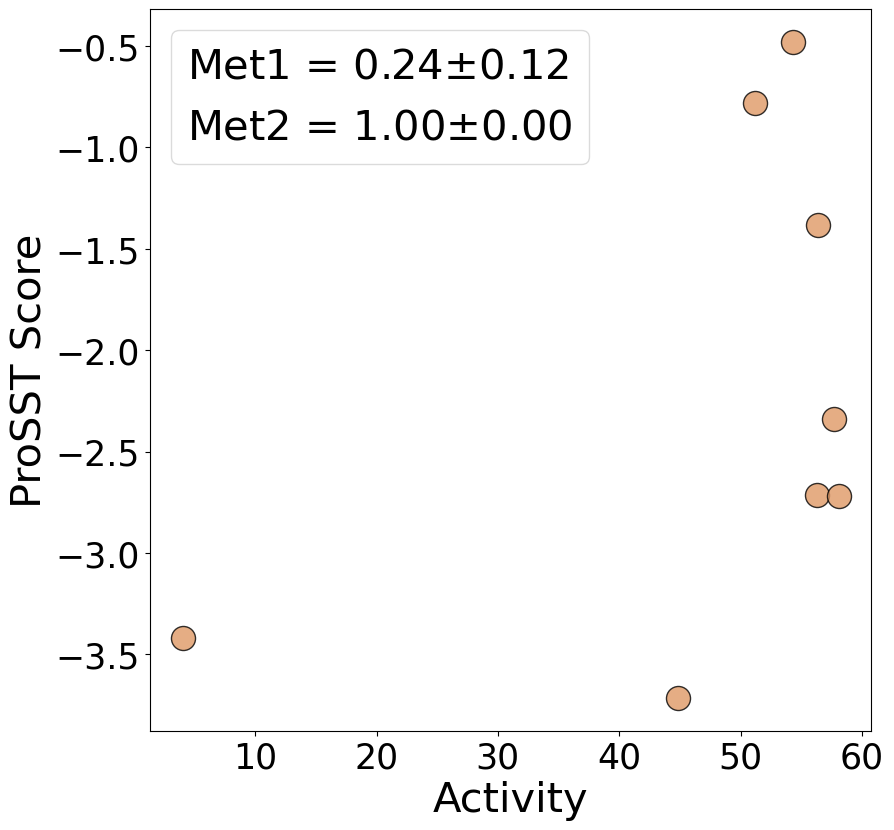

Worst Structure Model: ProtSSN


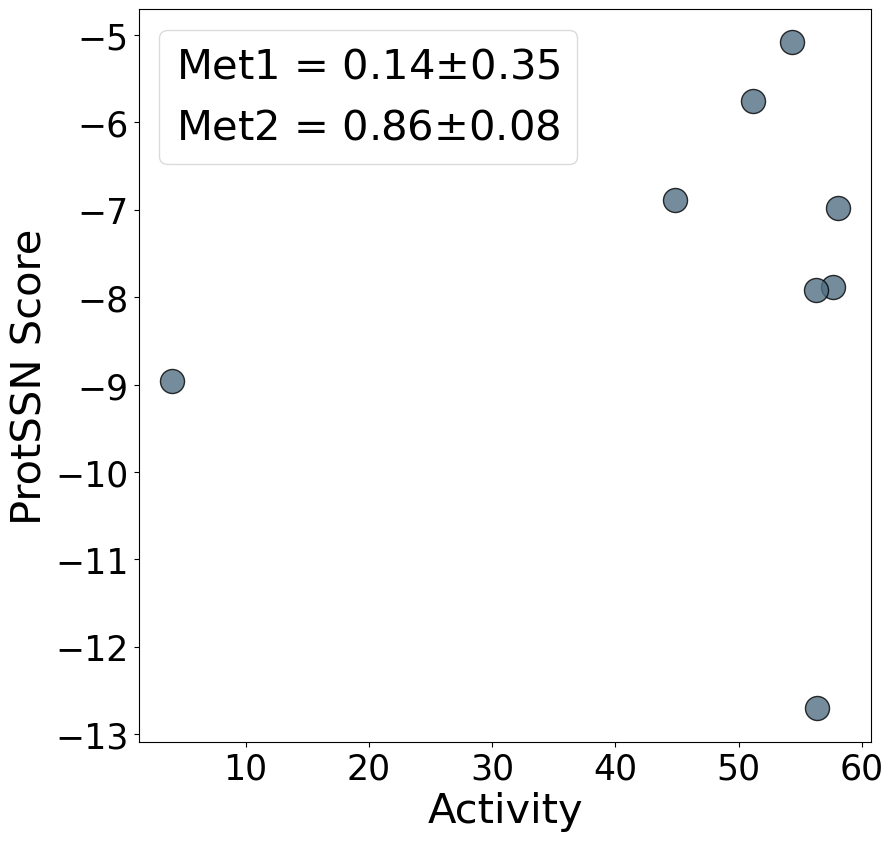

All features
Best Model using all features: VenusREM_4096


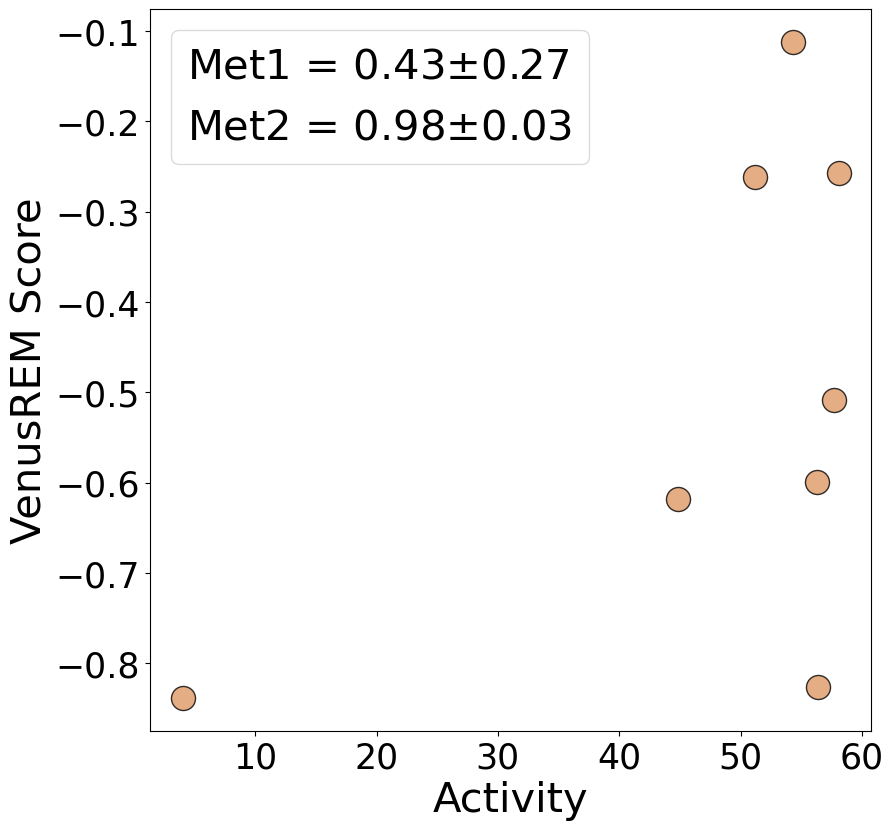

Worst Model using all features: RSALOR


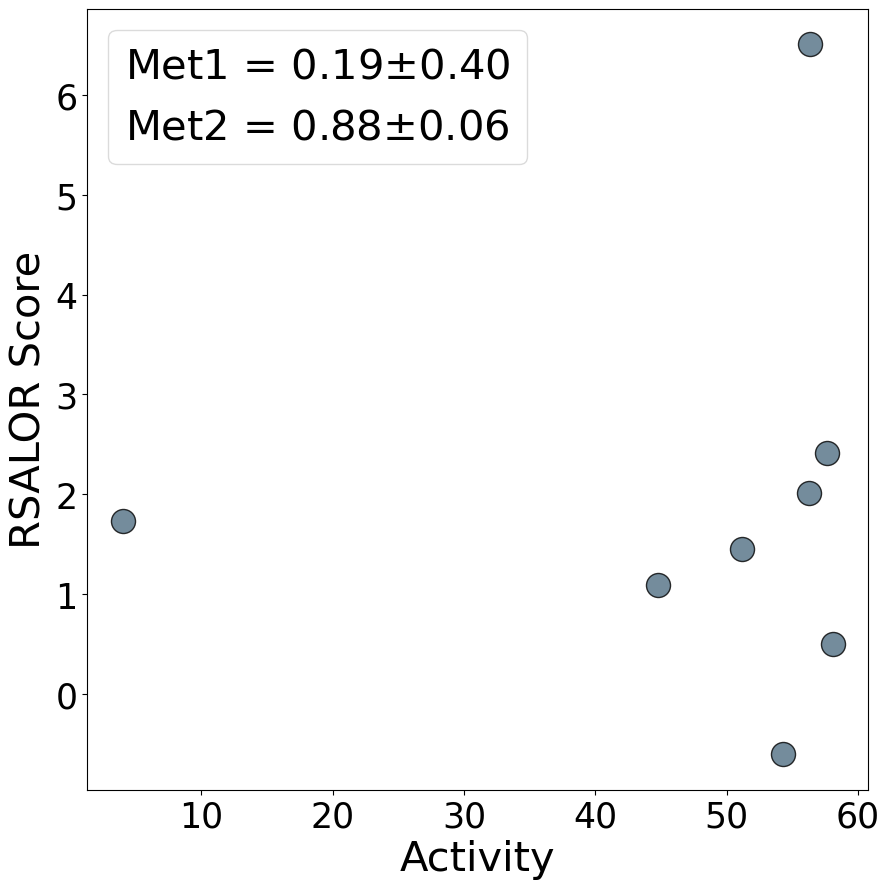

Plotting results for TOGT1_1_relact_clean
Overall Model
Best Overall Model: ESM2_150M


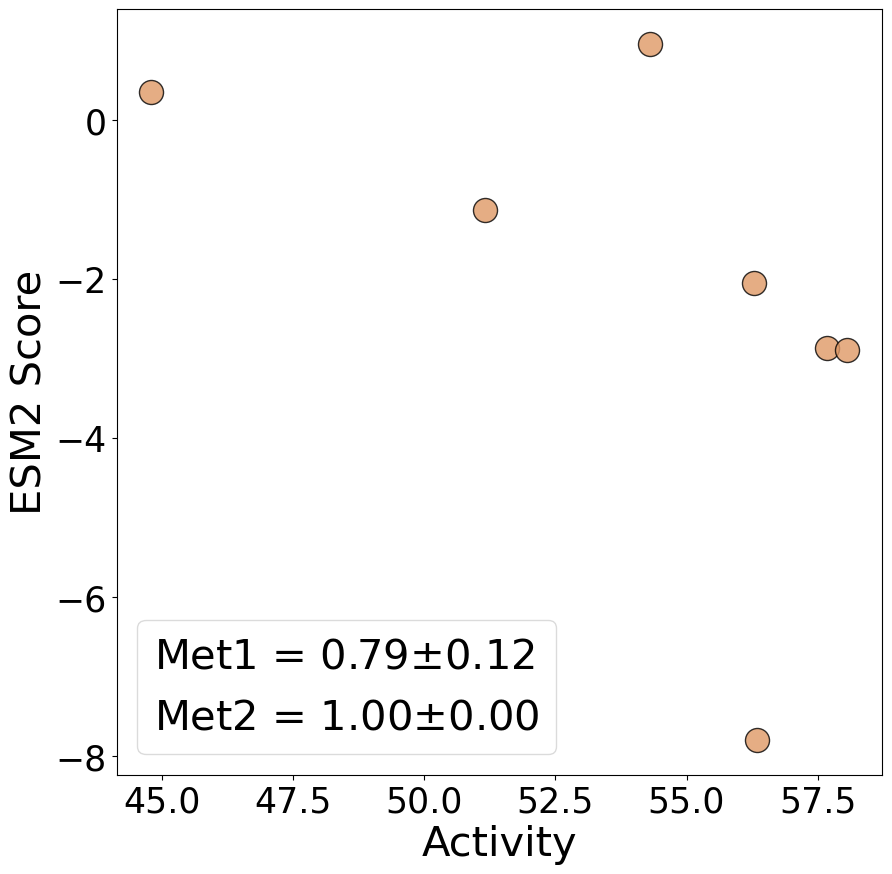

Worst Overall Model: ProtGPT2


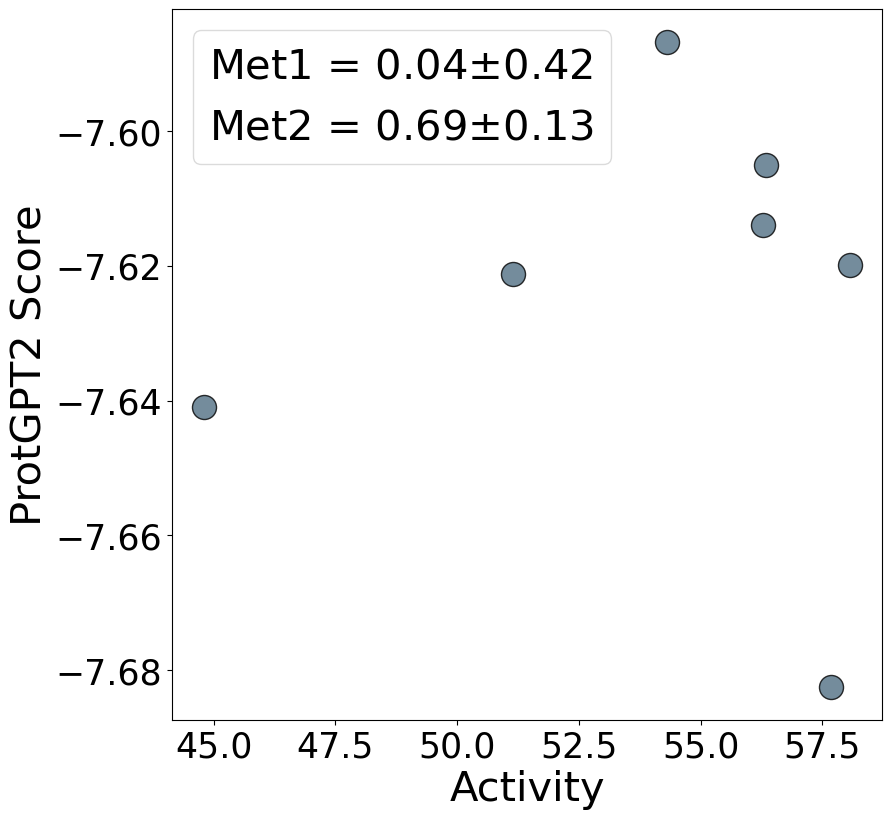

Sequence Model
Best Sequence Model: ESM2_150M


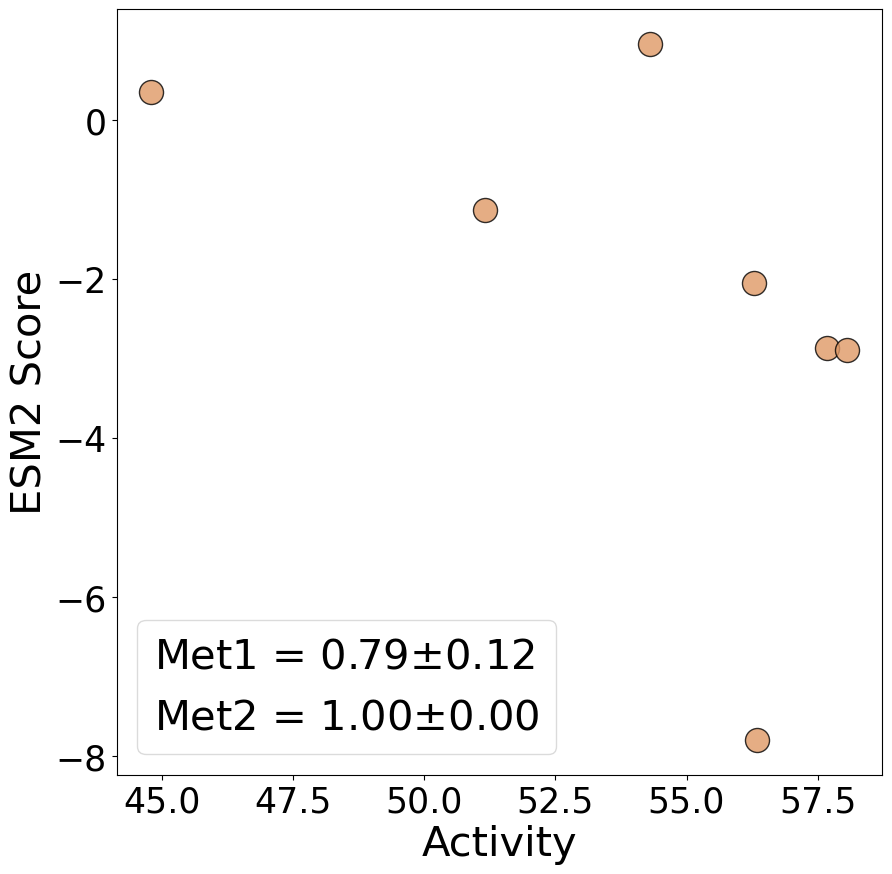

Worst Sequence Model: ProtGPT2


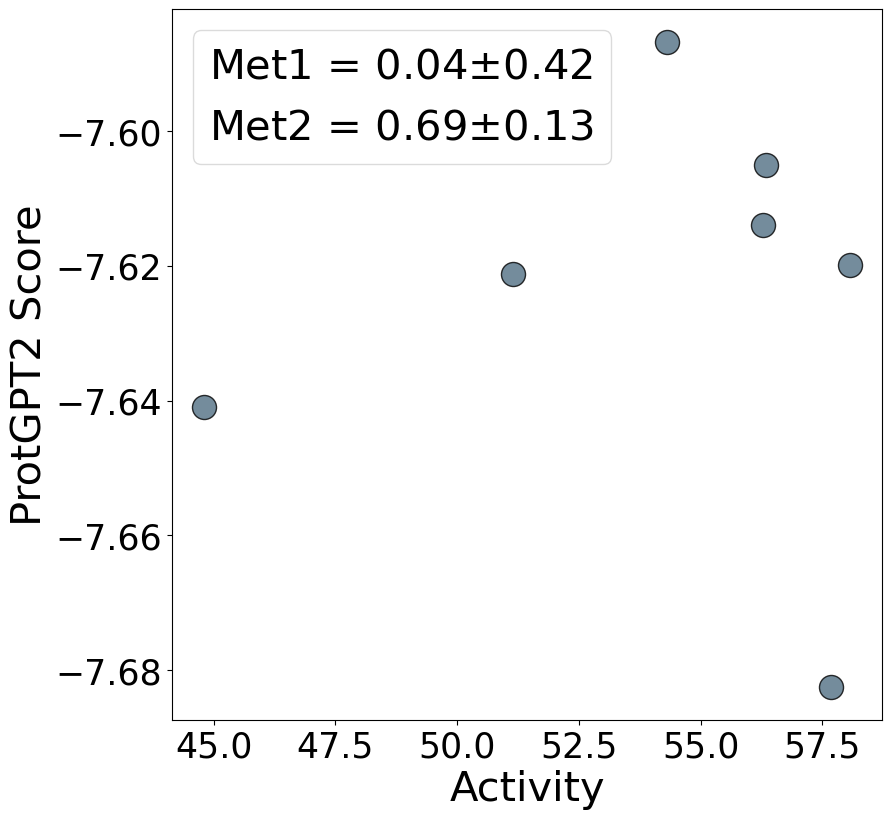

MSA Model
Best MSA Model: GEMME


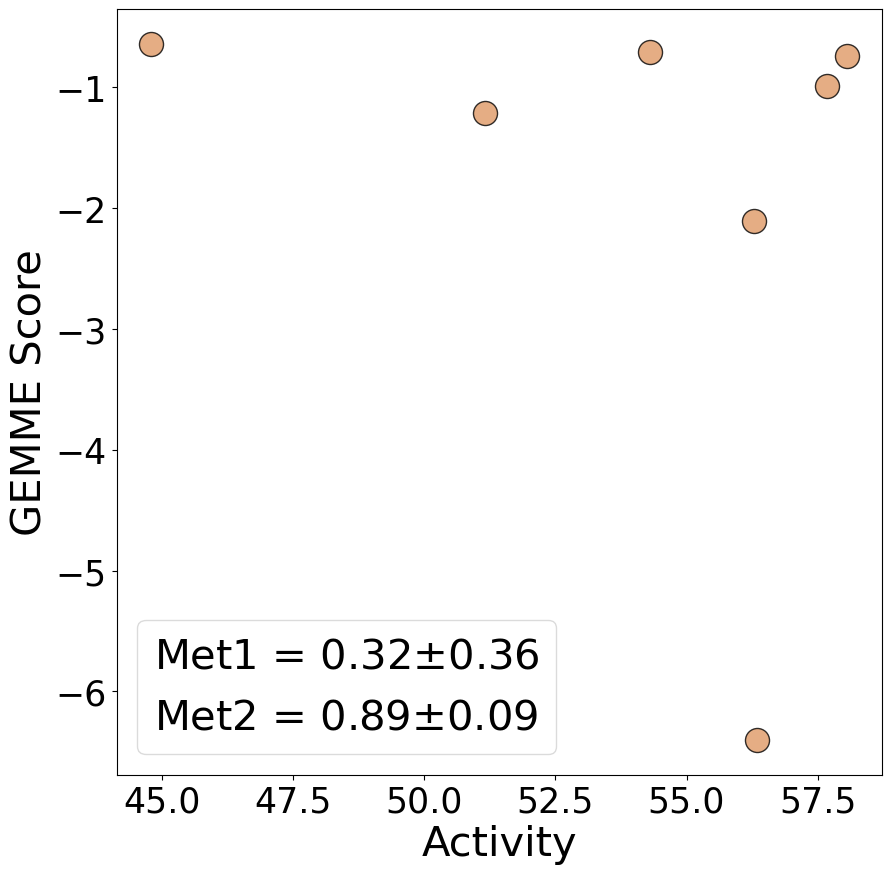

Worst MSA Model: EVE


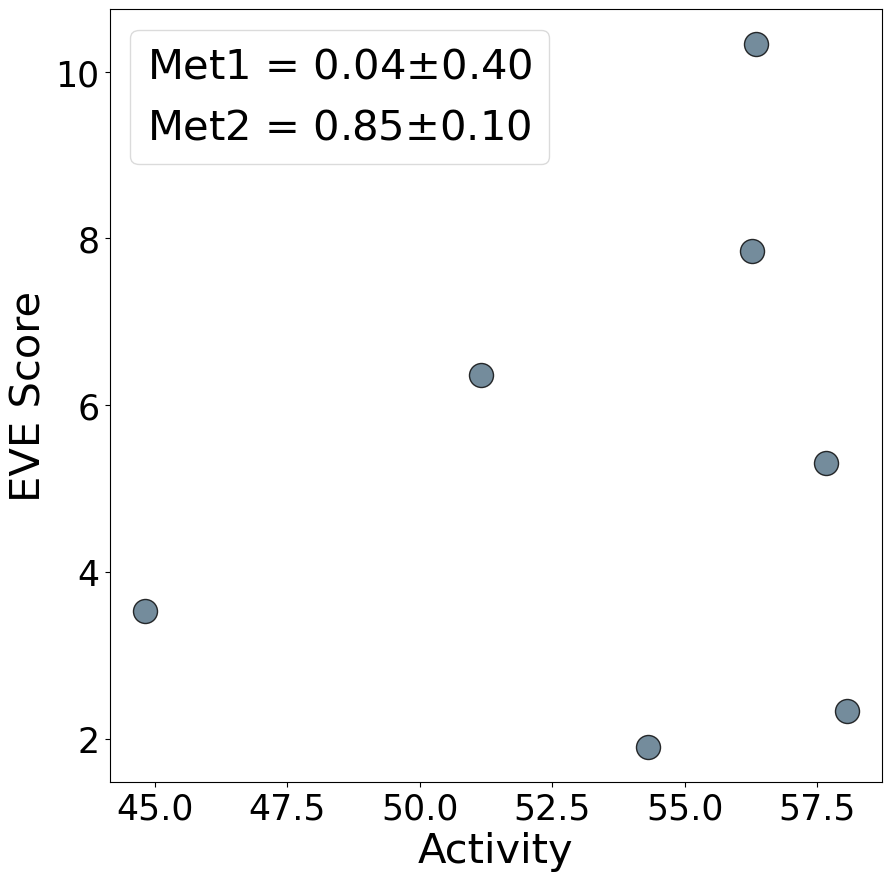

Structure Model
Best Structure Model: ProtSSN


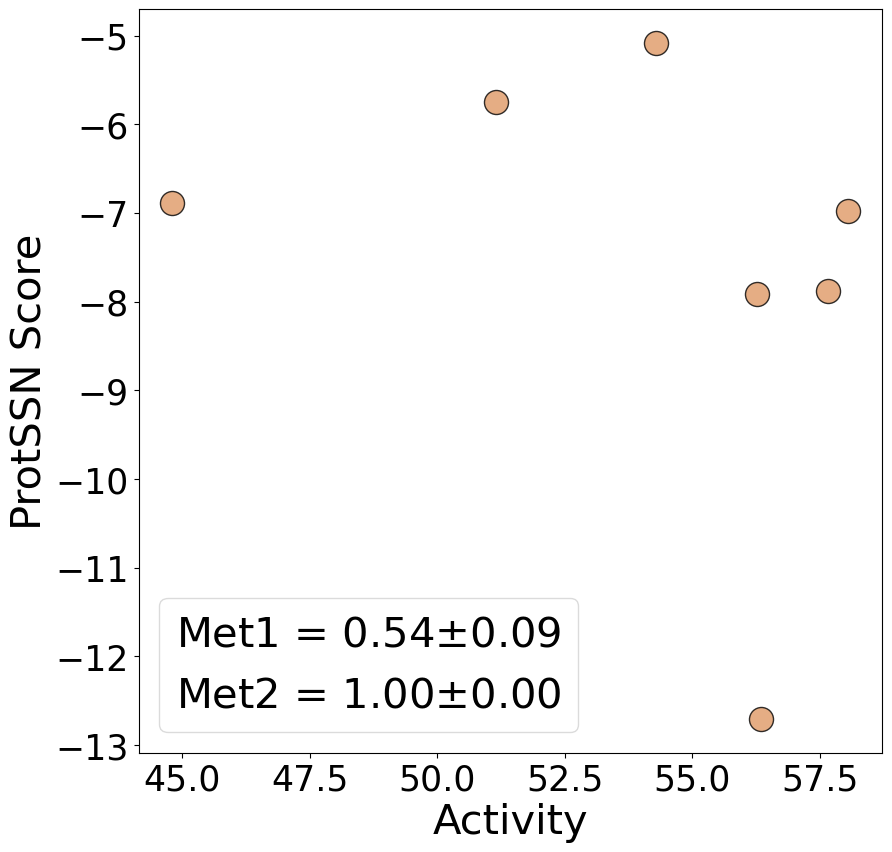

Worst Structure Model: MULAN_small


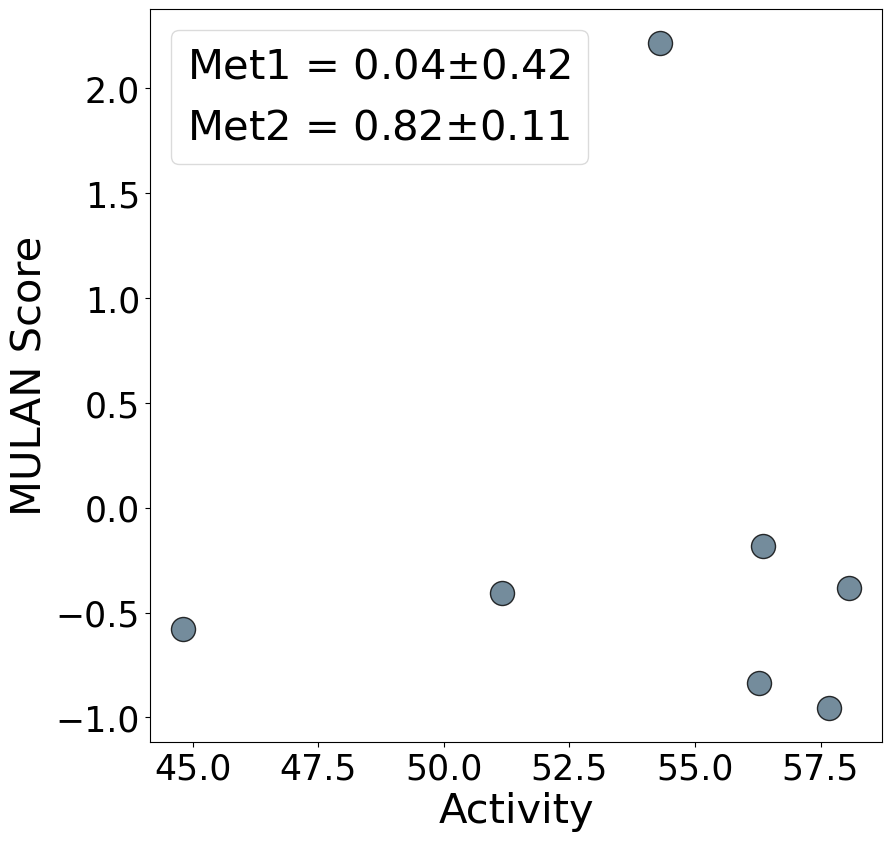

All features
Best Model using all features: RSALOR


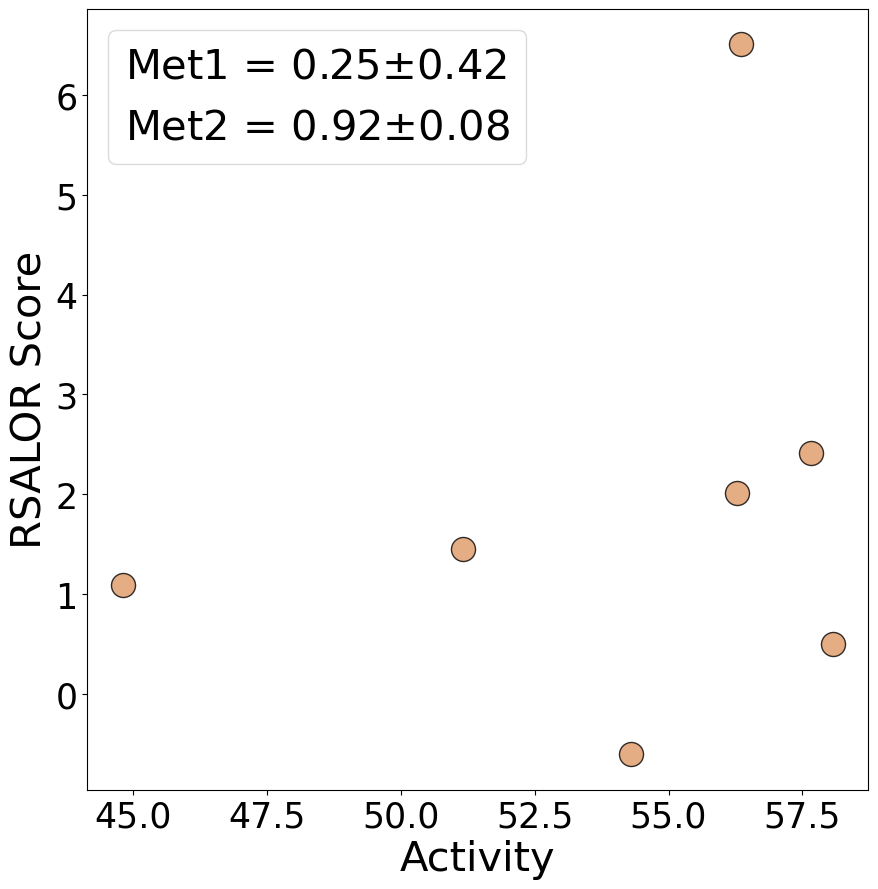

Worst Model using all features: VenusREM_512


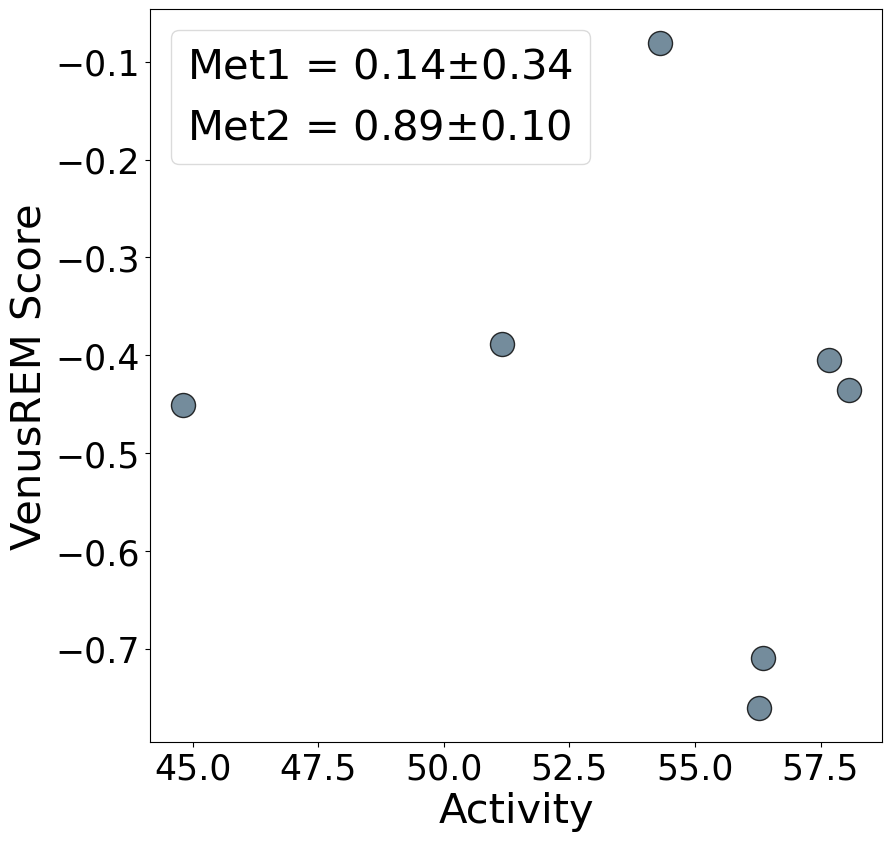

In [40]:
# Plotting the performance of the best model
# Met1 = Absolute Spearman correlation
# Met2 = Average Precision
exp_property = 'Activity'
worst_color = '#516f84'
for name in lowN_name:
    print(f'Plotting results for {name}')

    print('Overall Model')
    best_ = zsm_module.best_models[name]['overall']
    best_score_name = best_.split('_')[0]
    worst_ = zsm_module.worst_models[name]['overall']
    worst_score_name = worst_.split('_')[0]
    print('Best Overall Model:',best_)
    zsmplt.zs_vs_exp_scatter(zsm_module,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst Overall Model:',worst_)
    zsmplt.zs_vs_exp_scatter(zsm_module,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)

    print('Sequence Model')
    best_ = zsm_module.best_models[name]['sequence']
    best_score_name = best_.split('_')[0]
    worst_ = zsm_module.worst_models[name]['sequence']
    worst_score_name = worst_.split('_')[0]
    print('Best Sequence Model:',best_)
    zsmplt.zs_vs_exp_scatter(zsm_module,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst Sequence Model:',worst_)
    zsmplt.zs_vs_exp_scatter(zsm_module,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)

    print('MSA Model')
    best_ = zsm_module.best_models[name]['MSA']
    best_score_name = best_.split('_')[0]
    worst_ = zsm_module.worst_models[name]['MSA']
    worst_score_name = worst_.split('_')[0]
    print('Best MSA Model:',best_)
    zsmplt.zs_vs_exp_scatter(zsm_module,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst MSA Model:',worst_)
    zsmplt.zs_vs_exp_scatter(zsm_module,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)

    print('Structure Model')
    best_ = zsm_module.best_models[name]['structure']
    best_score_name = best_.split('_')[0]
    worst_ = zsm_module.worst_models[name]['structure']
    worst_score_name = worst_.split('_')[0]
    print('Best Structure Model:',best_)
    zsmplt.zs_vs_exp_scatter(zsm_module,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst Structure Model:',worst_)
    zsmplt.zs_vs_exp_scatter(zsm_module,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)

    print('All features')
    best_ = zsm_module.best_models[name]['all']
    best_score_name = best_.split('_')[0]
    worst_ = zsm_module.worst_models[name]['all']
    worst_score_name = worst_.split('_')[0]
    print('Best Model using all features:',best_)
    zsmplt.zs_vs_exp_scatter(zsm_module,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst Model using all features:',worst_)
    zsmplt.zs_vs_exp_scatter(zsm_module,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)





ESM-IF1


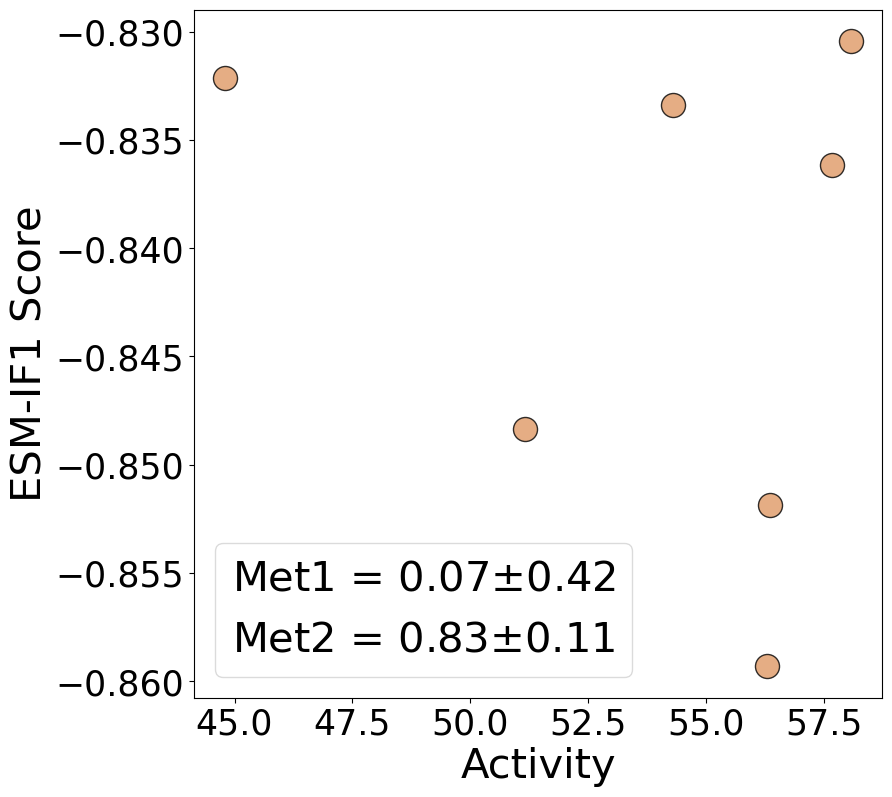

ProteinMPNN


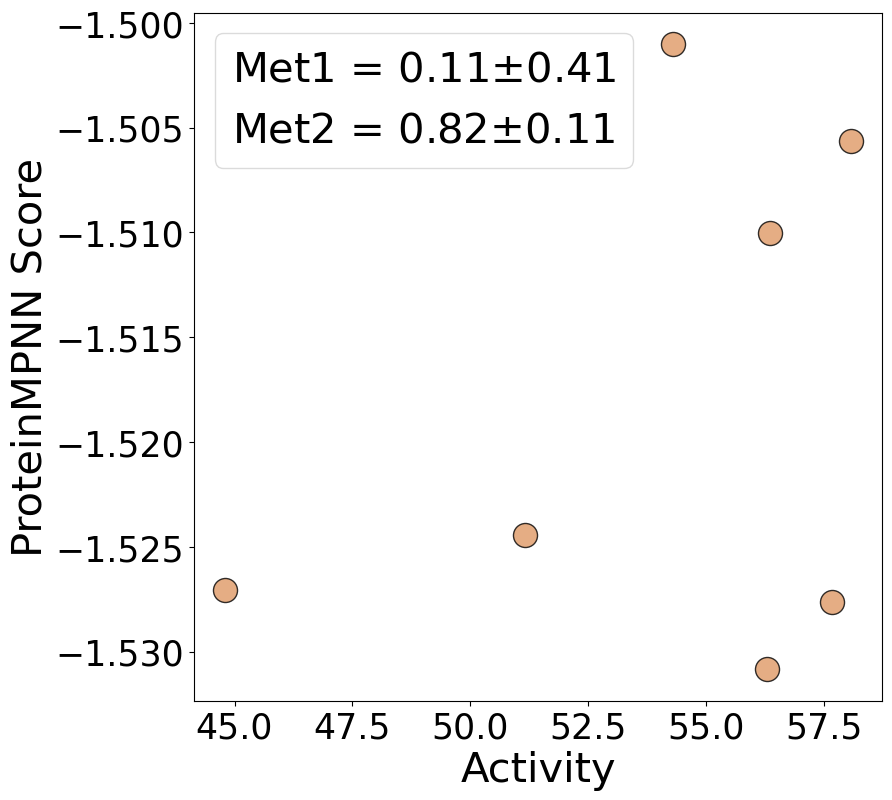

ProtGPT2


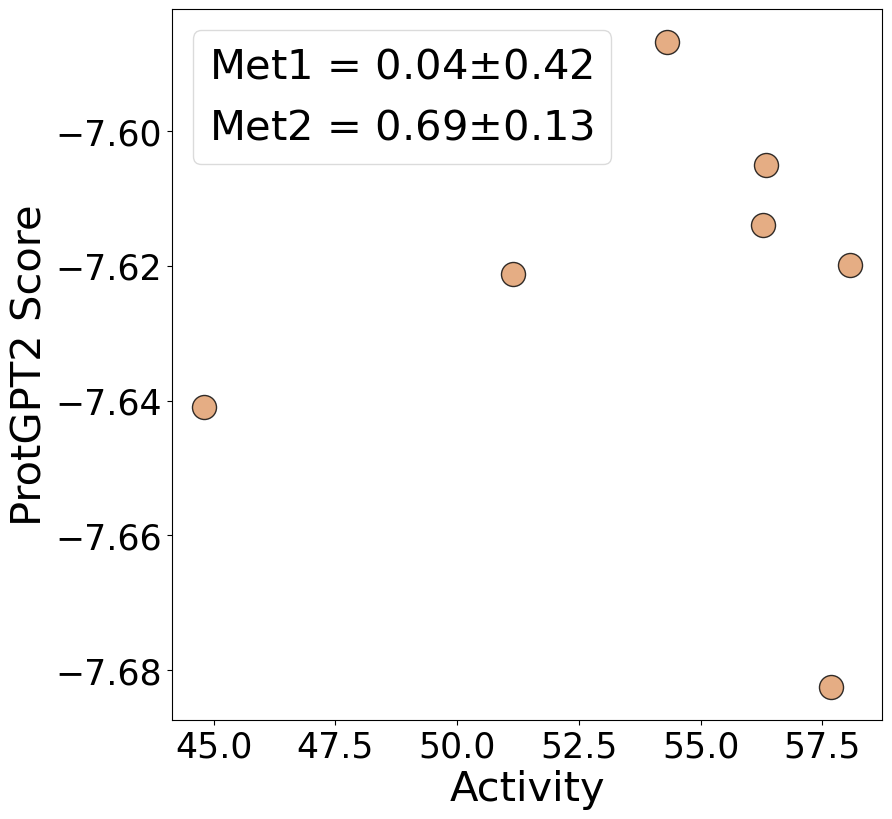

UniRep


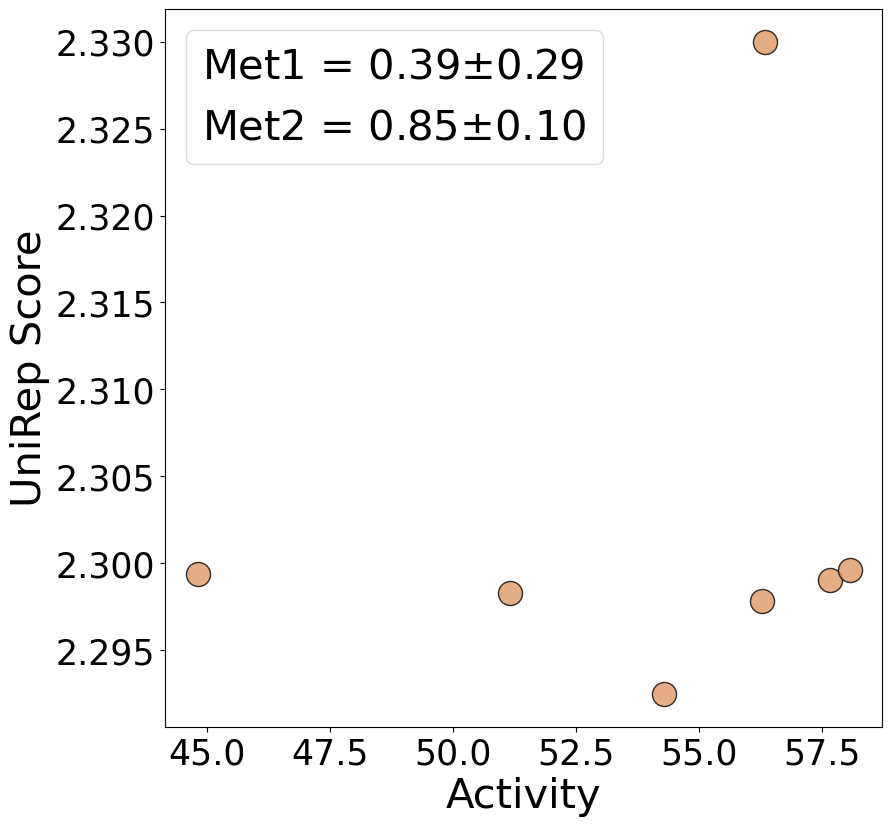

eUniRep


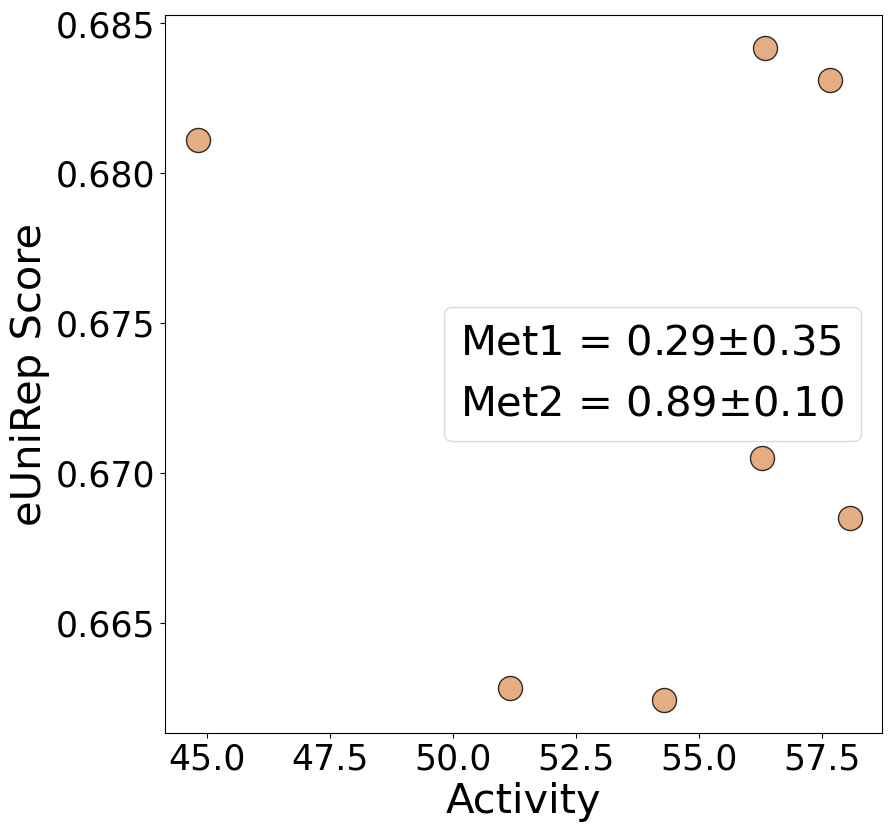

CARP_600K


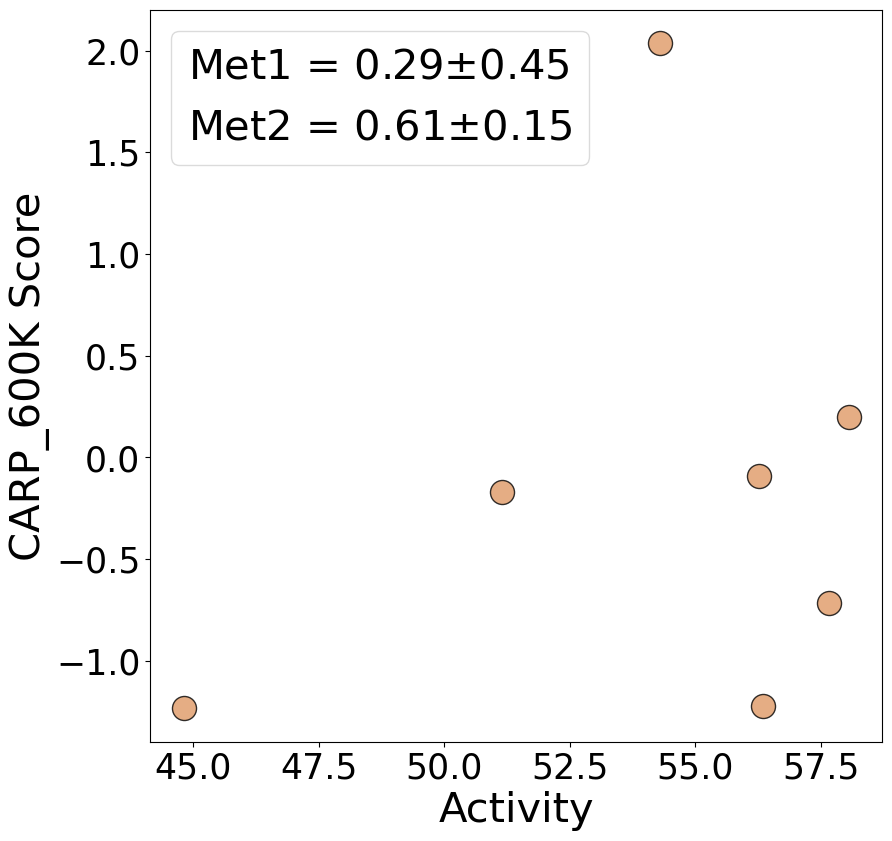

MIF


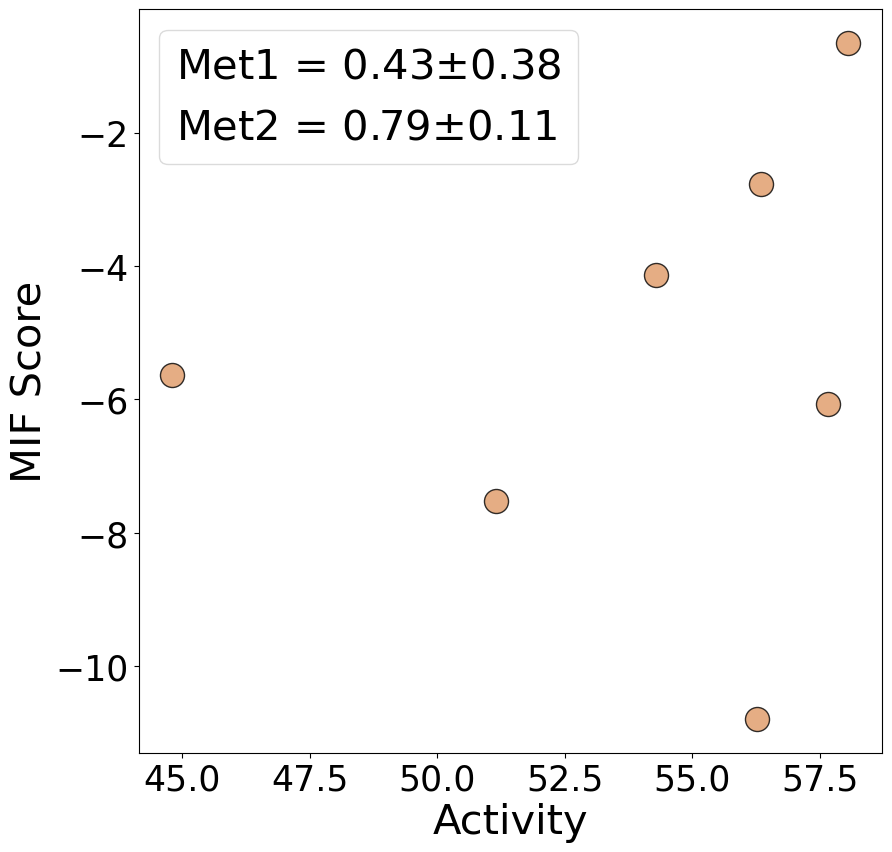

ProSST_20


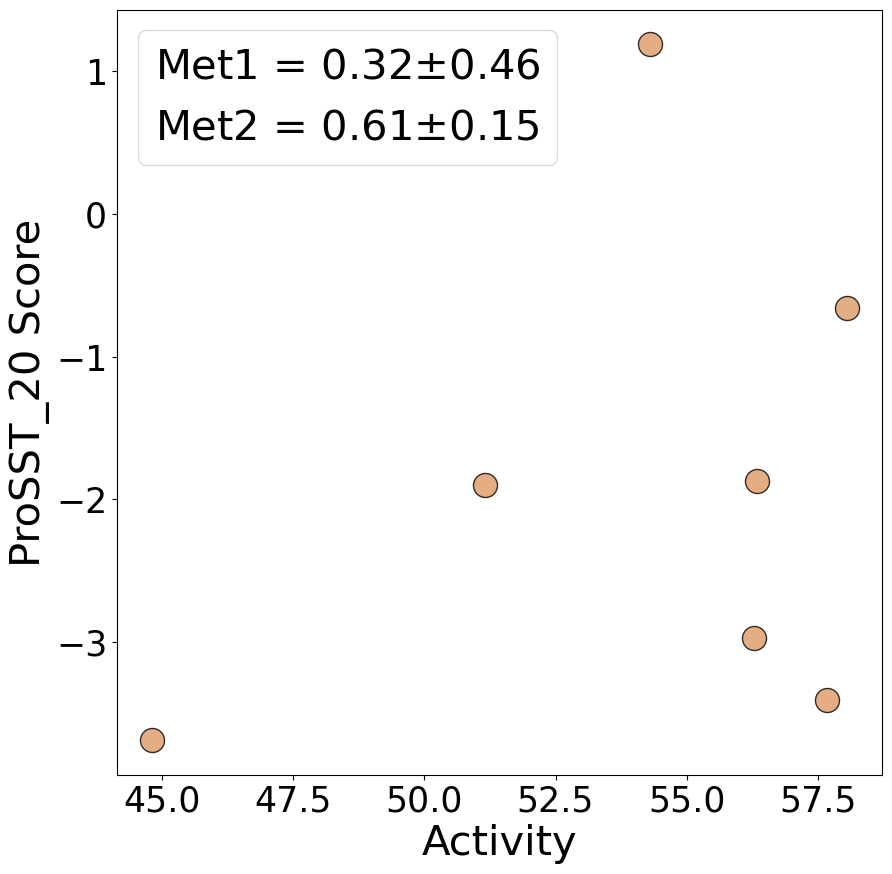

ProSST_128


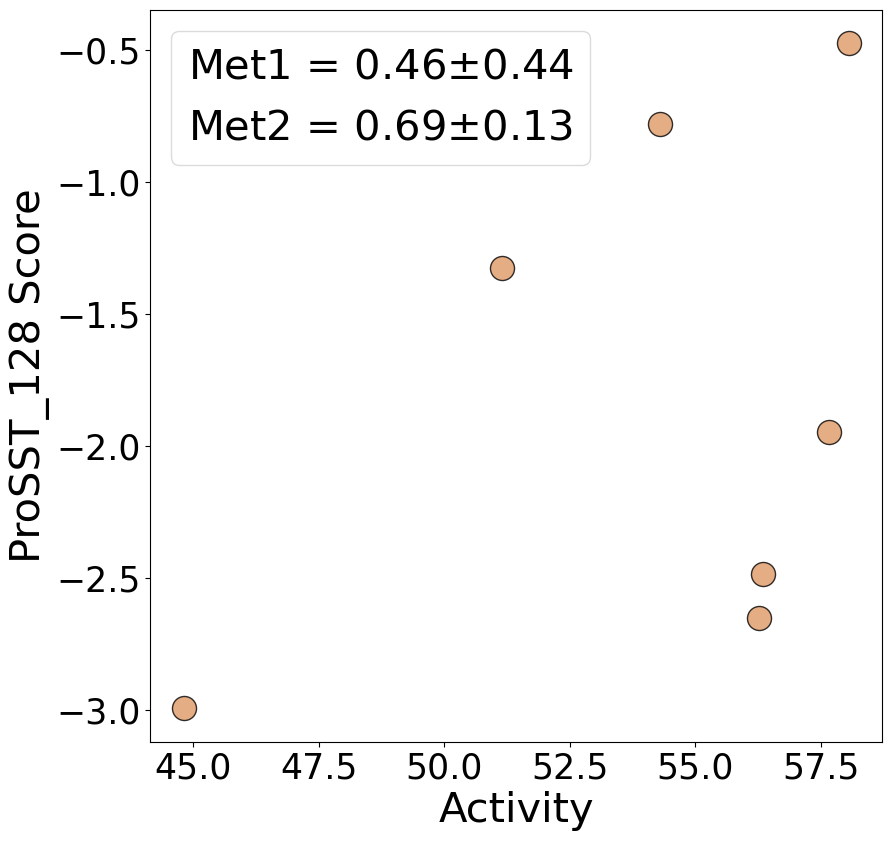

ProSST_4096


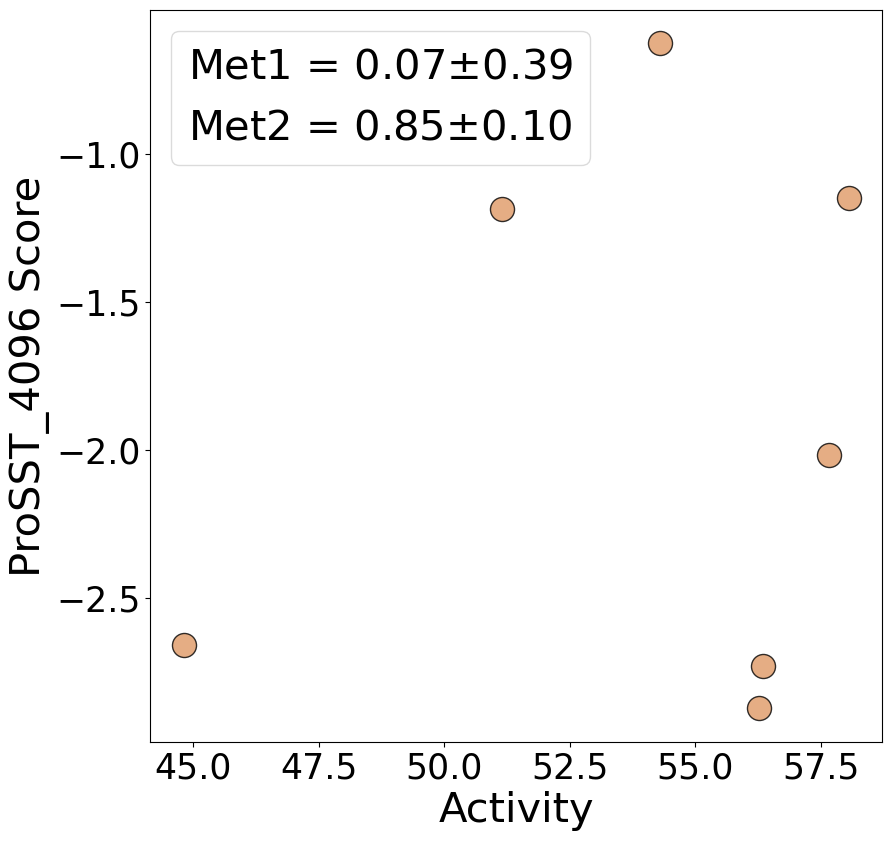

RSALOR


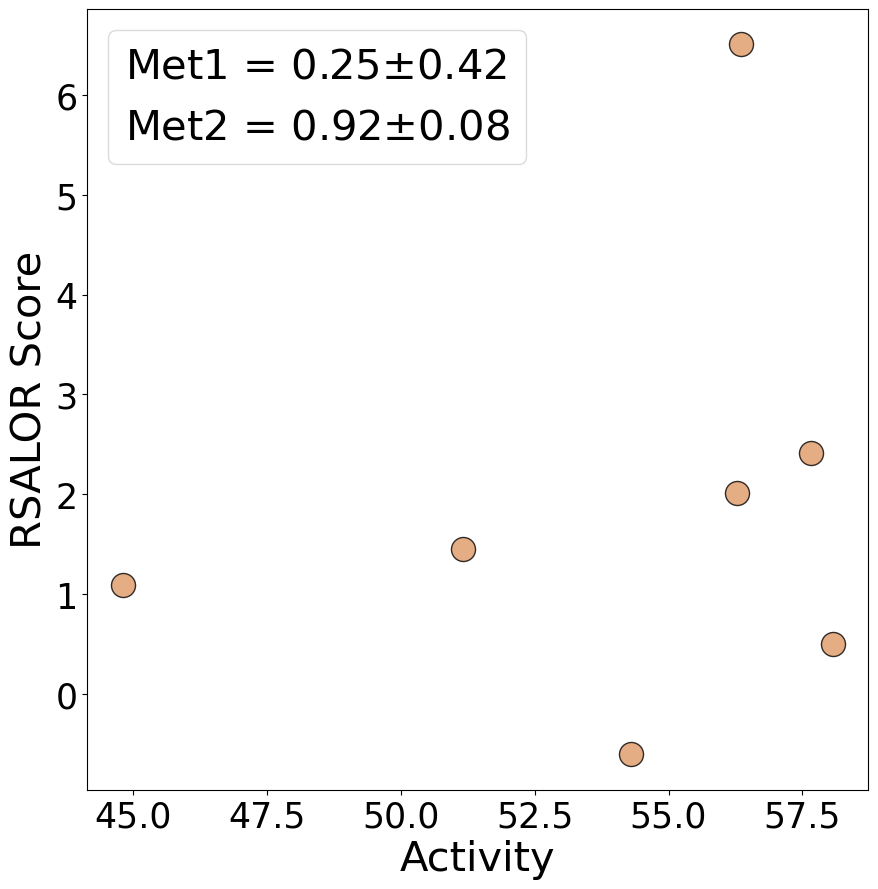

VenusREM_20


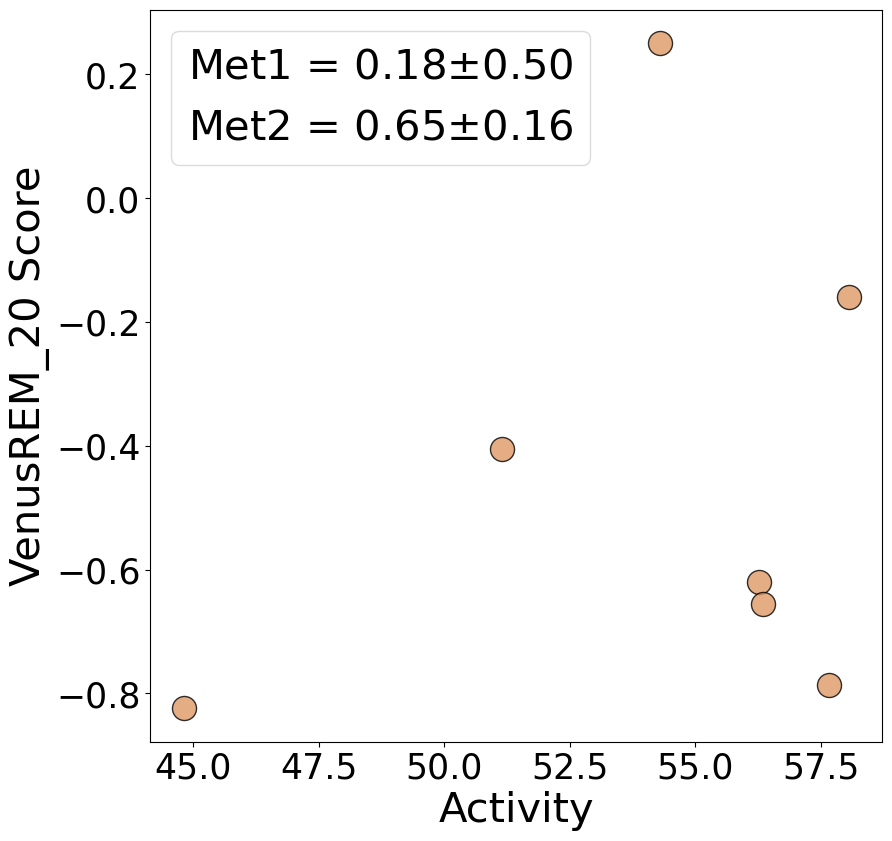

VenusREM_128


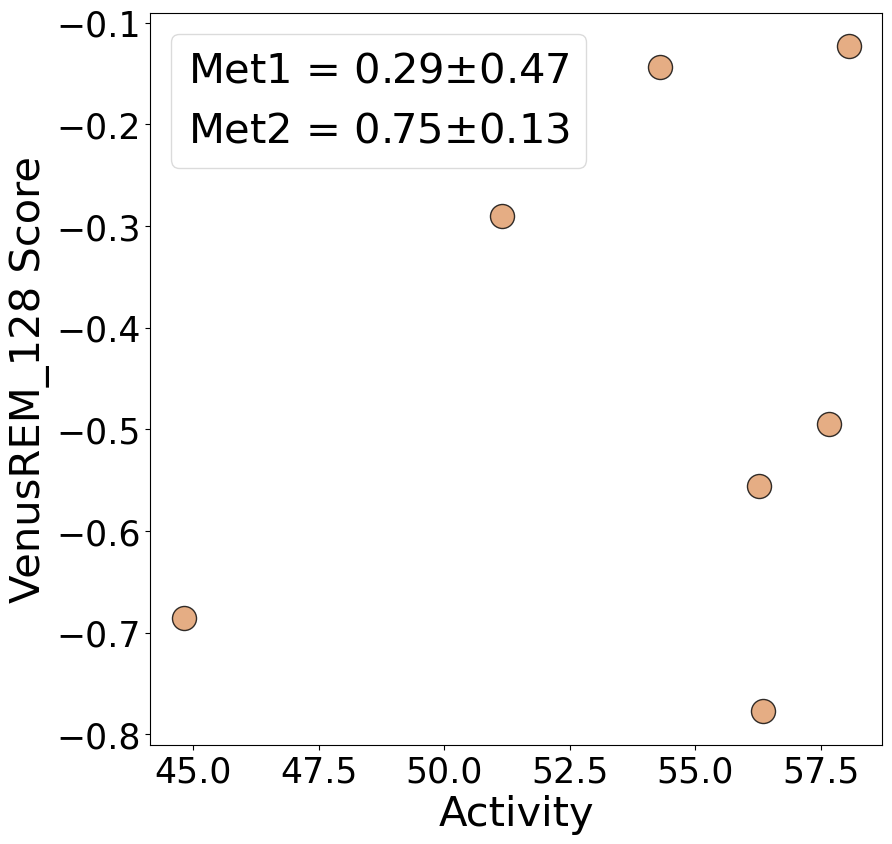

VenusREM_4096


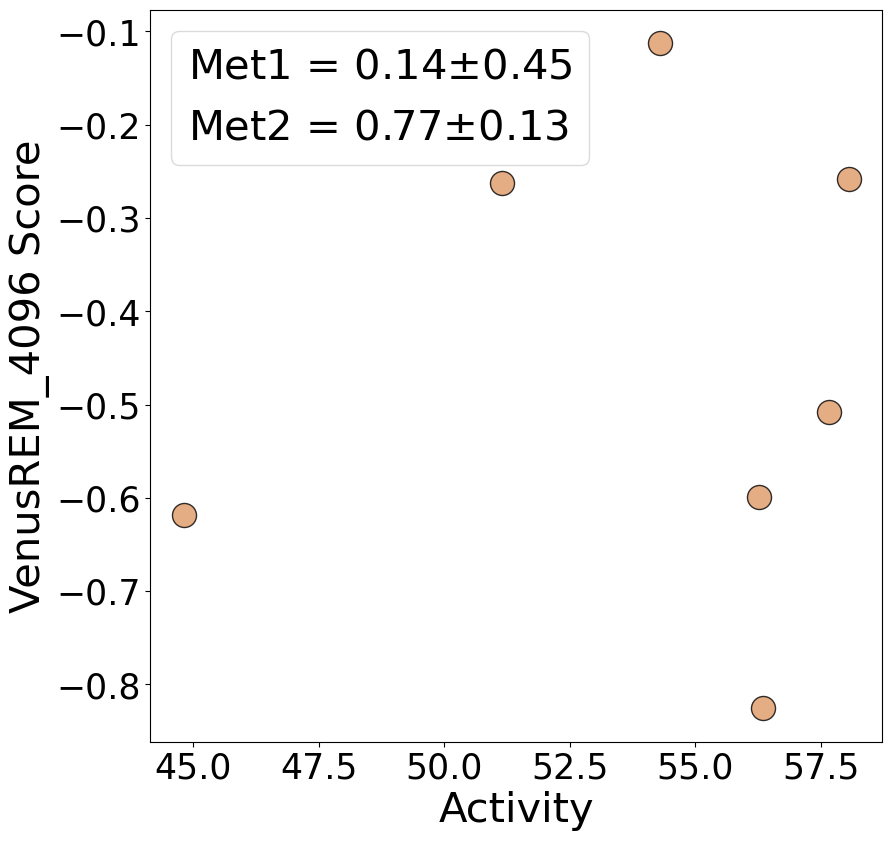

In [41]:
for model in correct_sign:
    print(model)
    zsmplt.zs_vs_exp_scatter(zsm_module,'TOGT1_1_relact_clean',model,custom_zsname=model,custom_expname=exp_property, format='png',reg_plot=False)

---

# Exploitation - In-silico Library

After having identified the best models, we can use them to score the mutants of an in silico library. Again, this section assumes that the user has already obtaiend the ZS scores for the mutants of interest. If this hasn't been done, please run the "Make in-silico library" section and run the ZSM calculation pipeline for the best models.

## Make in-silico library

The code below demonstrates how to use the best models to score the mutants of an in silico library. The full single-mutant landscape for FlA HIM is here used as an example

---

In [10]:
# Change the values of the following variables as needed
dataset_name = 'TOGT1_1'
library_suffix = 'SMscan'
numb_mut = [1] # For both single and double mutants, use the format [1,2]
wt_seq = 'MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVFSKSIQRNKYLGIEIEIRLIKFPAVENDLPEECERLDQIPSDDKLSNFFKATAMMQEPLEQLIEECRPNCLVSDMFLPWTTDSAAKFNIPRIVFHGTSFFALCVENSVRLNKPYKNVSSDAETFVVPNLPHEIKLTRTQLSPFEQSGEETAMTRMIKTVRESDSKSYGVVFNSFYELETDYVEHYTKVLGRRAWAIGPLSMCNRDIEDKAERGKKSSIDKHECLKWLDSKKPSSVVYVCFGSVANFTASQLHELAMGIEASGQEFIWVVRTELDNEDWLPEGFEERTKEKGLIIRGWAPQVLILDHESVGAFVTHCGWNSTLEGVSGGVPMVTWPVFAEQFFNEKLVTEVLKTGAGVGSIQWKRSASEGVKREAIAKAIKRVMVSEEAEGFRNRAKAYKEMARKAVEEGGSSYTGLTTLLEDISTYTSTGH'

In [16]:
# Generate the insilico library
insilico_library = zsm_module.insilico_library(dataset_name,numb_mut,wt_seq=wt_seq,custom_name=library_suffix)

---

## Single-points Mutants

### Load dataset

The in silico library ZS scores for the best models identied in the Exploration phase is loaded. The same wildtype threshold is used as in the previous phase

---

In [11]:
# Change the values of the following variables as needed
dataset_name = 'TOGT1_1'
library_suffix = 'SMscan'
model_list_selection = ['ESM2','VenusREM','ESM1b'] # Best models from each category
library_name = dataset_name+'_'+library_suffix+'_insilico_library'

In [12]:
zsm_module.set_threshold(library_name,wt_threshold[0])
zsm_module.load_scores(library_name,model_list_selection,wt=True)

---

### Sort and Rank library

In this section, the in silico libraries are sorted and ranked based on the best models obtained from the Exploration phase. This can be used to identify mutants for experimental validation.

It should be noted that the order of the ranking is based on maximizing the Spearman Correlation. Please see PRIZM documentation for how to change this


---

In [13]:
# Define the best models from each category and the overall best model
best_models = [zsm_module.best_models[lowN_name[0]][cat] for cat in ['sequence','all','structure']] # Best models from each category
best_overall = zsm_module.best_models[lowN_name[0]]['overall'] # Best overall model, used for final sorting

In [14]:
best_models

['ESM2_650M', 'VenusREM_4096', 'ProSST_1024']

In [15]:
library_ranking = zsm_module.sorting_mutants(library_name,['VenusREM_4096'],best_overall,'../results/',wt=True,previous_metrics=zsm_module.metric_results[lowN_name[0]])

In [16]:
library_ranking

,mutant,mutated_sequence,WT,Mut,Pos,VenusREM,VenusREM_rank,VenusREM_bin
7608,G401I,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[G],[I],[401],1.620893,1.0,1
4531,W239I,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[W],[I],[239],1.428741,2.0,1
1363,N72S,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[N],[S],[72],1.295725,3.0,1
1349,N72A,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[N],[A],[72],1.252913,4.0,1
7618,G401V,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[G],[V],[401],1.233674,5.0,1
...,...,...,...,...,...,...,...,...
447,A24K,MGQLHFFFFPMMAHGHMIPTLDMKKLVASRGVKATIITTPLNESVF...,[A],[K],[24],-4.048508,9039.0,0
6872,G362P,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[G],[P],[362],-4.252641,9040.0,0
450,A24P,MGQLHFFFFPMMAHGHMIPTLDMPKLVASRGVKATIITTPLNESVF...,[A],[P],[24],-4.258015,9041.0,0
8038,I424R,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[I],[R],[424],-4.279654,9042.0,0


---

The binary results can be used to identify mutants where more than one ZS predictor predicts it to be above wildtype.

It should be noted that for the given example (FlA HIM single-mutant landscape), not mutant are predicted to be above wildtype for all three models.

---

### Plotting model predictions

Using PRIZM, the user is able to plot and compare the predictions of three different models.

Any catalytic residues and positions of interest can also be highlighted to examine their patterns. As an example, the original mutational sites (interface positions) are plotted for the FlA HIM

---

---

### Single-Mutant Landscapes

ZeroShotModeller enables the user to generate and plot the full single-mutant landscape for a given model.

Again, FlA HIM is used as an example, with the best models identified in the Exploration phase (ESM-IF1, ESM1b, and TranceptEVE) being used to generate the landscapes.

---

In [15]:
# Change the values of the following variables as needed
landscape_rows = 4

In [16]:
# Generating the SM landscapes for the three models
for model in ['ESM2_650M', 'VenusREM_4096']:
    zsm_module.sm_landscape(library_name,model,wt=True)
binary_landscape = (zsm_module.landscape['TOGT1_1_SMscan_insilico_library']['VenusREM_4096']>0).astype(int)

In [10]:
zsmplt.heatmap(zsm_module, library_name, 'VenusREM_4096', landscape_rows, 'VenusREM Score',alpha=1,
               colors=['#34729F', 'white', '#F36906'], format='png',figsize=(60, 40))

NameError: name 'library_name' is not defined

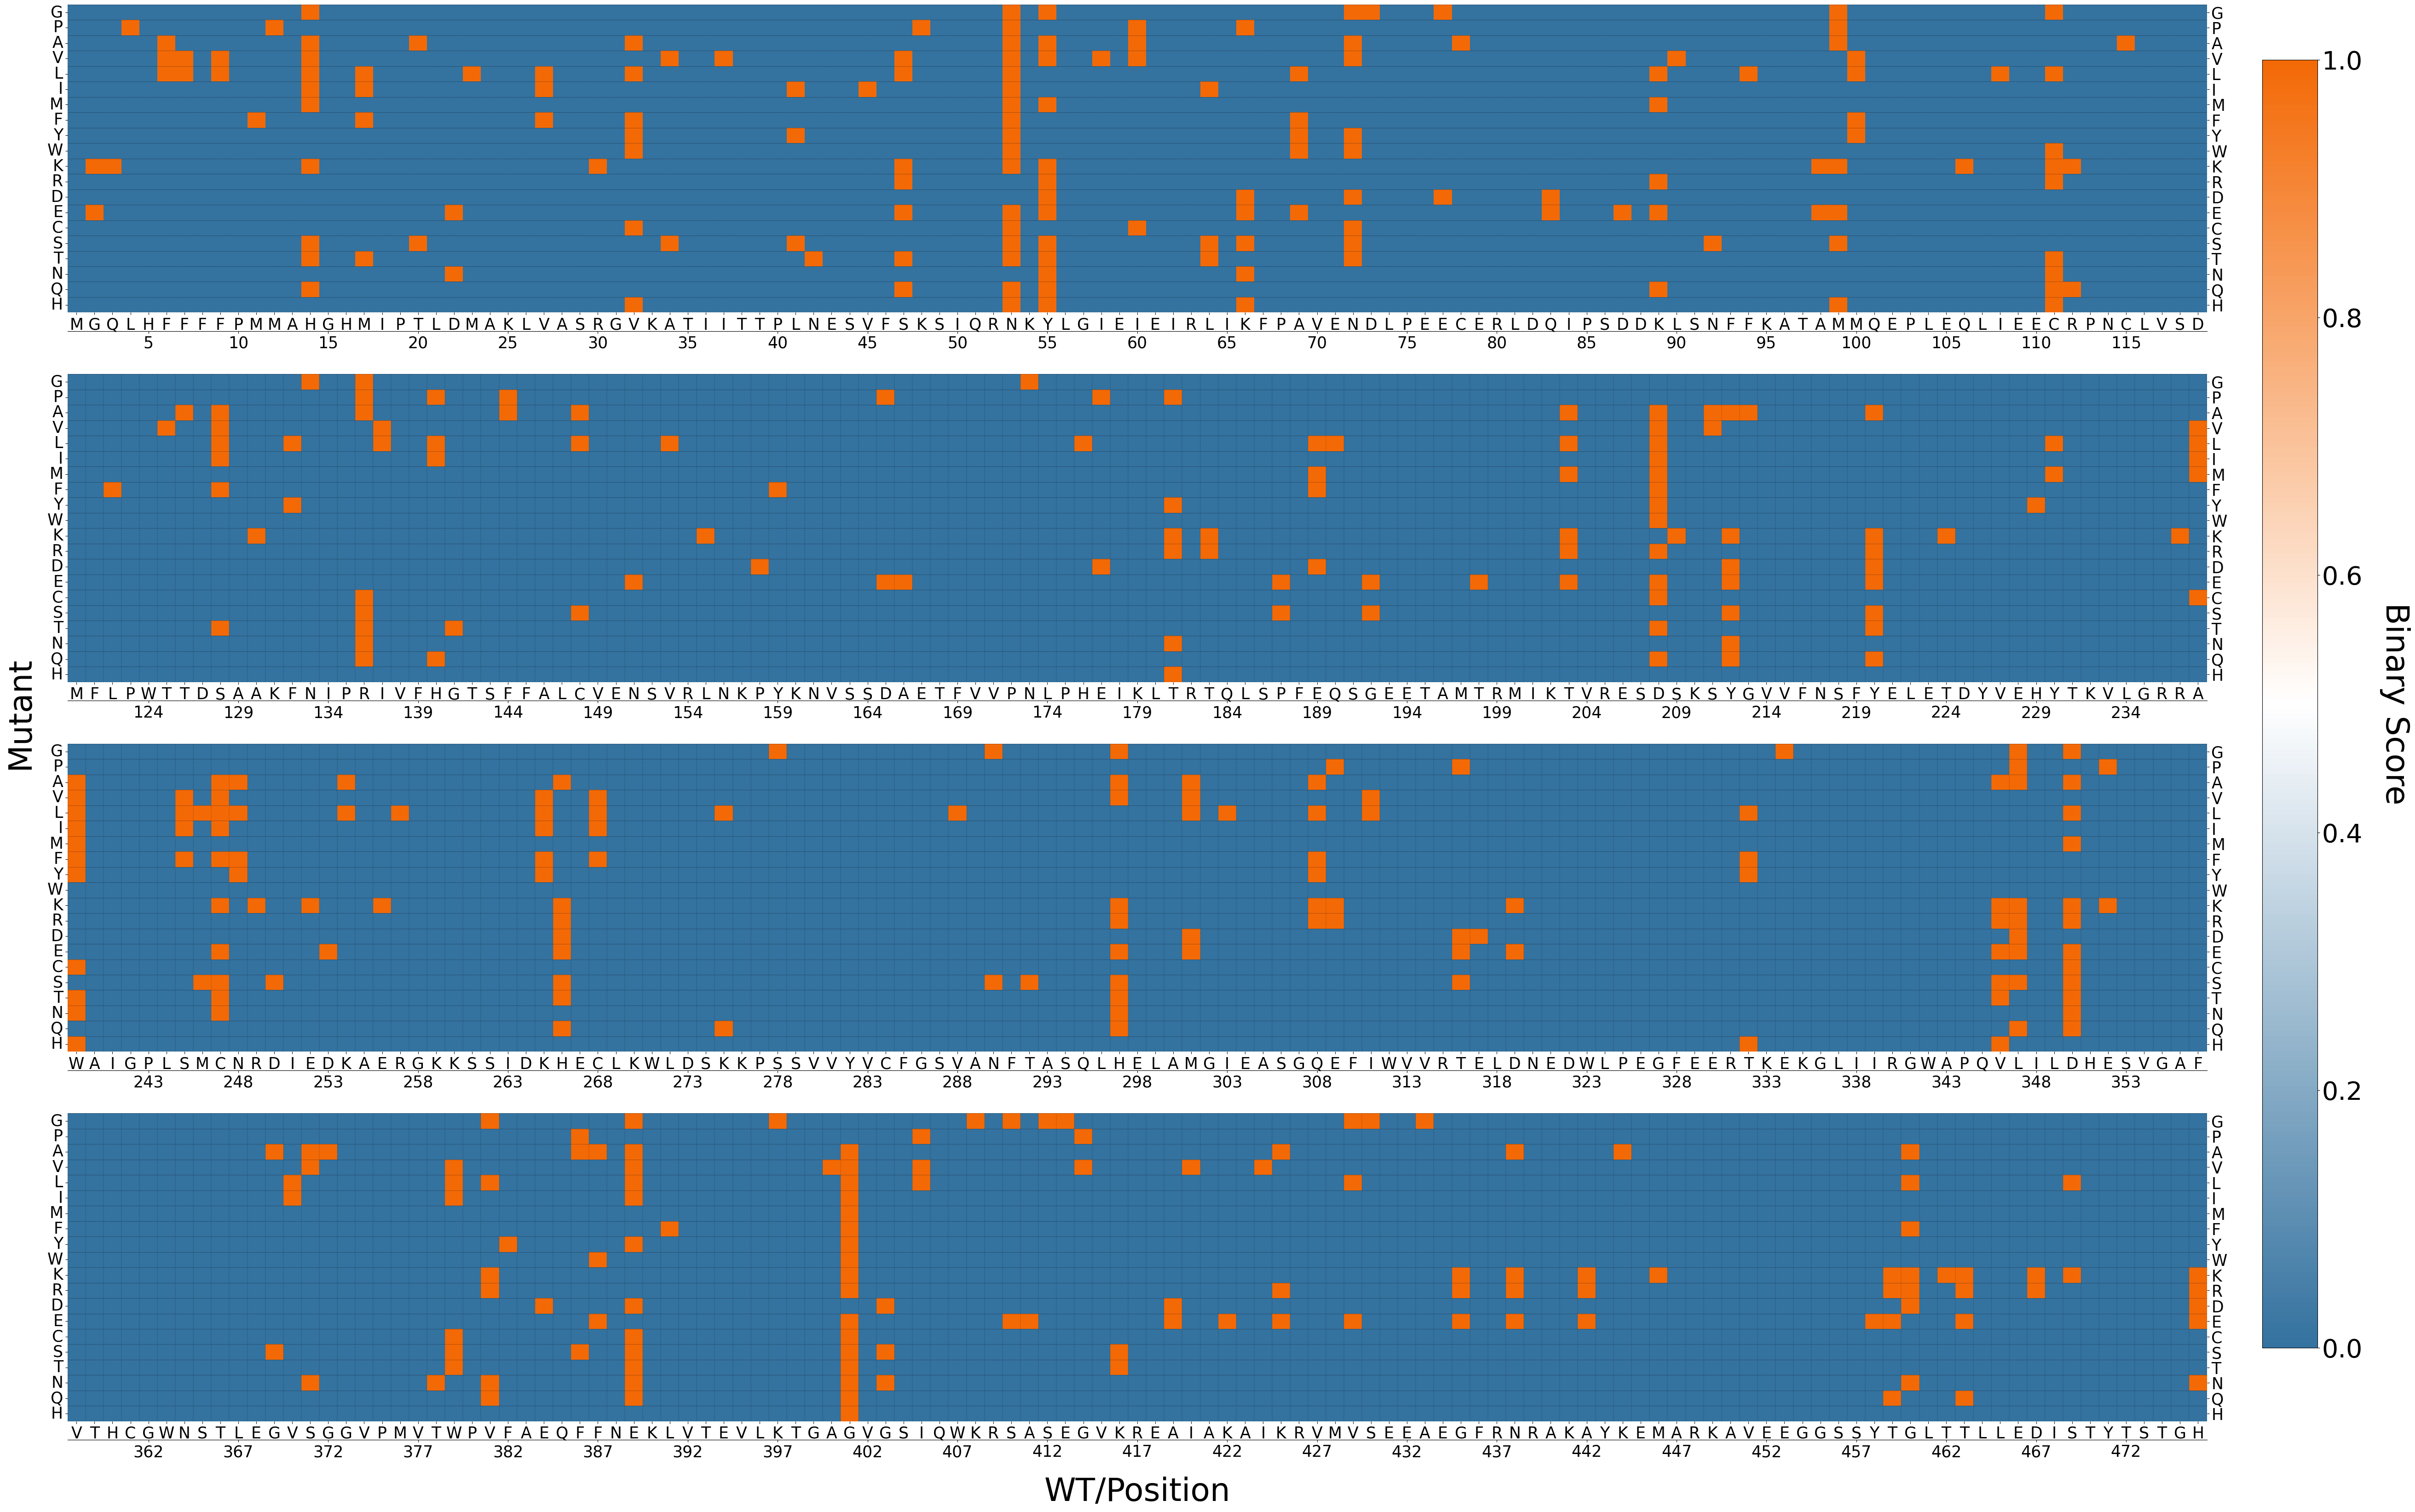

In [20]:
zsmplt.heatmap(zsm_module, library_name, 'VenusREM_4096', landscape_rows, 'Binary Score',alpha=1, landscape=binary_landscape, wt_score=0.5,
               colors=['#34729F', 'white', '#F36906'], format='png',figsize=(60, 40),landscape_name='binary_comb')

In [27]:
neg_mask = zsm_module.landscape['TOGT1_1_SMscan_insilico_library']['VenusREM_4096']<0
pos_landscape = zsm_module.landscape['TOGT1_1_SMscan_insilico_library']['VenusREM_4096'].copy()
pos_landscape[neg_mask] = -1

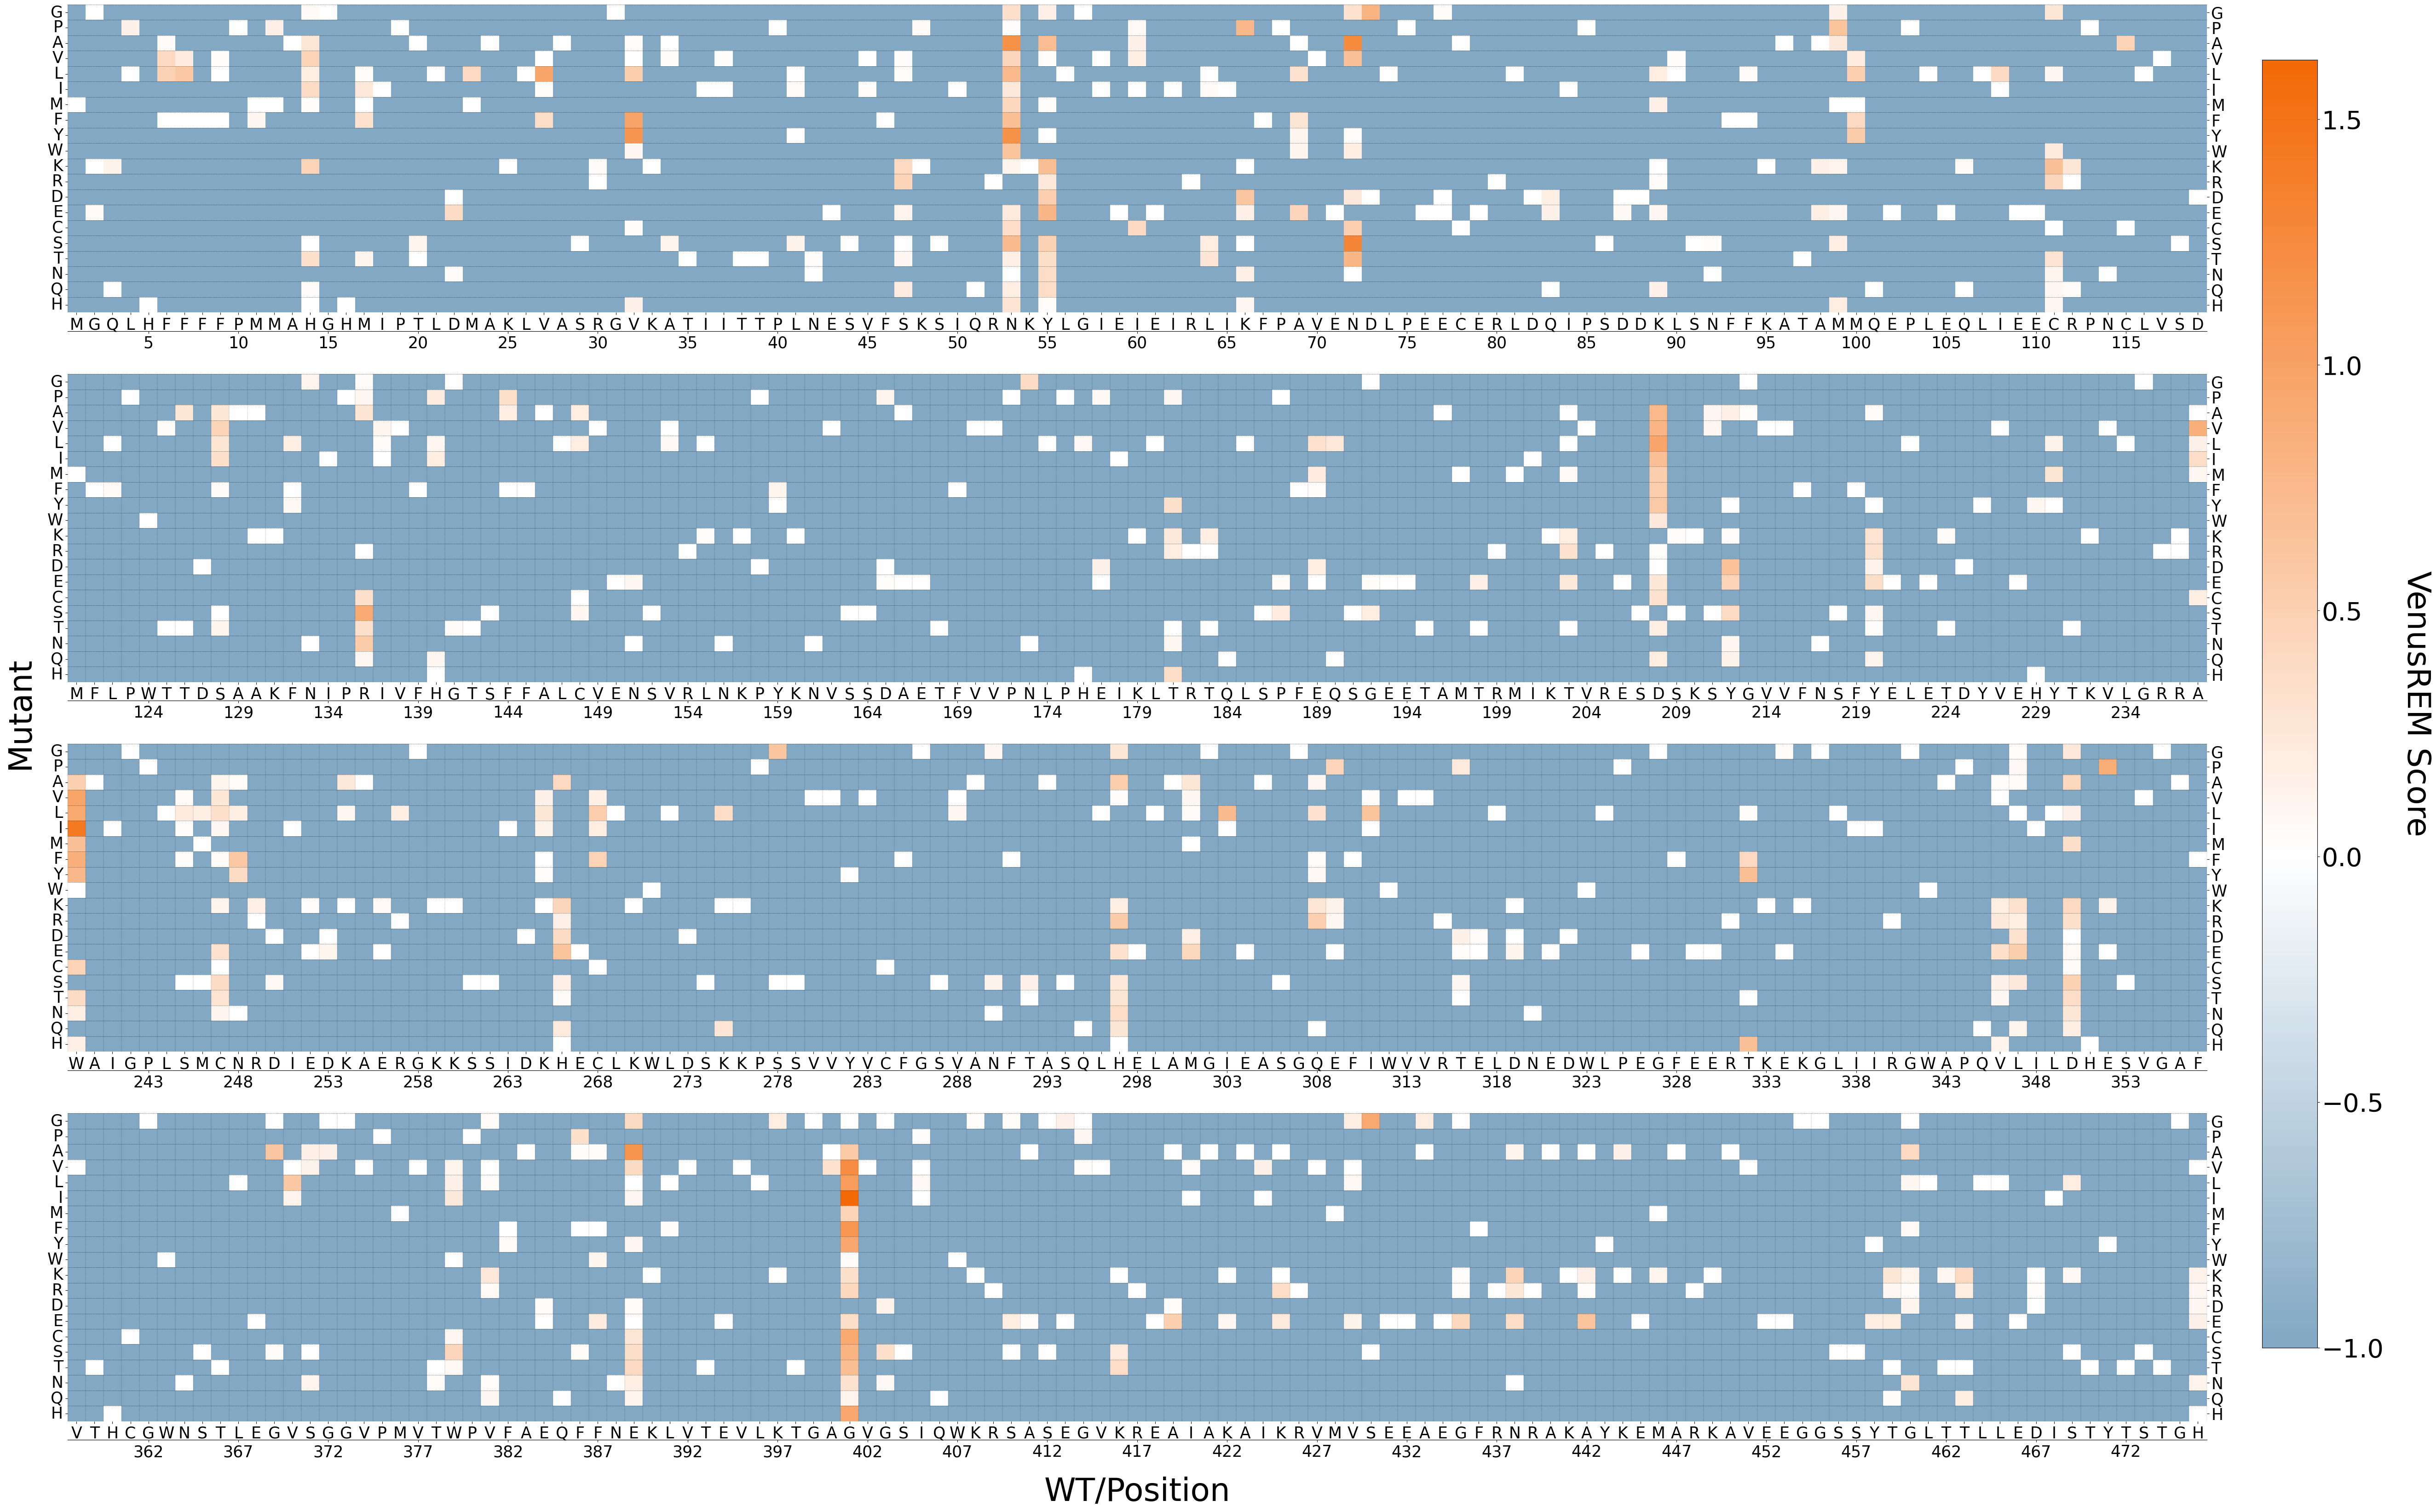

In [31]:
zsmplt.heatmap(zsm_module, library_name, 'VenusREM_4096', landscape_rows, 'VenusREM Score',alpha=1, landscape=pos_landscape, wt_score=0,
               colors=['#34729F', 'white', '#F36906'], format='png',figsize=(60, 40),landscape_name='VenusREM_pos')